DelayPro vs DelayPro: missing file
DelayPro vs DelayAnti: 88 scratch, 5 transfer -> ratio 0.06
DelayPro vs ReactPro: 5 scratch, 2 transfer -> ratio 0.40
DelayPro vs ReactAnti: 5 scratch, 3 transfer -> ratio 0.60
DelayPro vs CatPro: 7 scratch, 2 transfer -> ratio 0.29
DelayPro vs CatAnti: 3 scratch, 3 transfer -> ratio 1.00
DelayPro vs Match2Sample: inf scratch (max val 0.58) -> 0.40
DelayPro vs NonMatch2Sample: inf scratch (max val 0.76) -> 0.01
DelayPro vs CtxIntMod1: 99 scratch, 2 transfer -> ratio 0.02
DelayPro vs CtxIntMod2: 98 scratch, 8 transfer -> ratio 0.08
DelayAnti vs DelayPro: 93 scratch, 7 transfer -> ratio 0.08
DelayAnti vs DelayAnti: missing file
DelayAnti vs ReactPro: 5 scratch, 2 transfer -> ratio 0.40
DelayAnti vs ReactAnti: 5 scratch, 3 transfer -> ratio 0.60
DelayAnti vs CatPro: 7 scratch, 2 transfer -> ratio 0.29
DelayAnti vs CatAnti: 3 scratch, 3 transfer -> ratio 1.00
DelayAnti vs Match2Sample: inf scratch (max val 0.58) -> 0.40
DelayAnti vs NonMatch2Sample: inf s

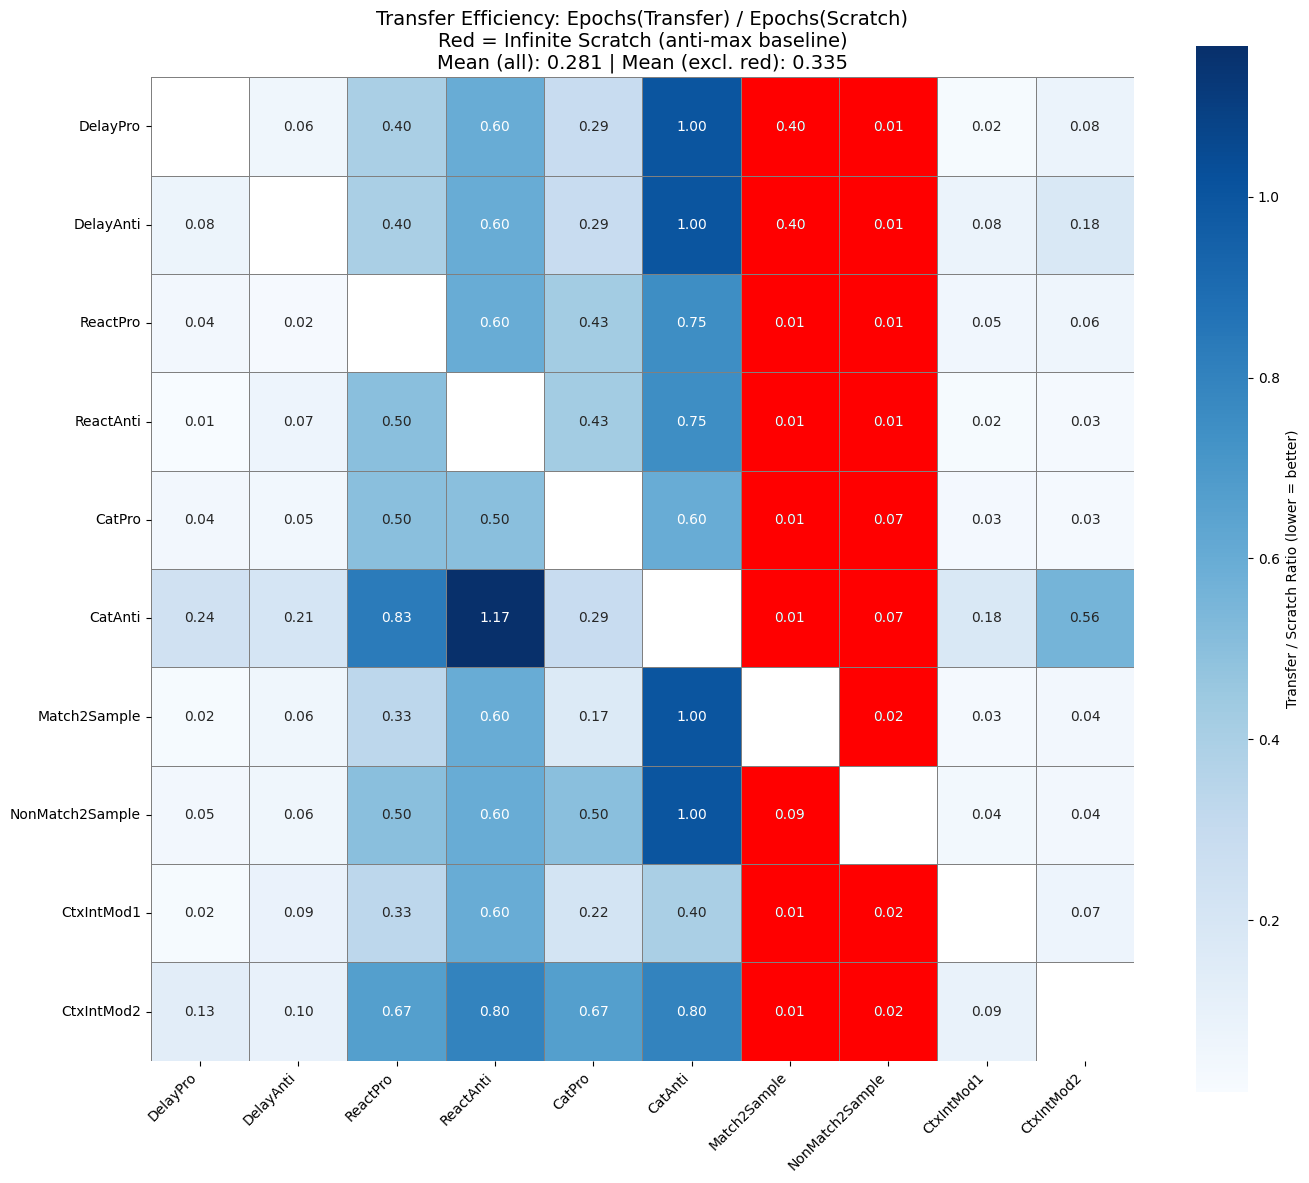

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


def epochs_to_threshold(acc_list, threshold=0.9):
    """
    Returns number of epochs (1-based) needed to reach acc > threshold.
    Returns np.inf if never reached.
    """
    for i, acc in enumerate(acc_list):
        if acc > threshold:
            return i + 1  # 1-based epoch count
    return np.inf


# Task list (10 tasks)
tasks = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", 
         "CatPro", "CatAnti", "Match2Sample", "NonMatch2Sample",
         "CtxIntMod1", "CtxIntMod2"]

n = len(tasks)
matrix = np.full((n, n), np.nan, dtype=float)   # NaN for missing
inf_mask = np.full((n, n), False, dtype=bool)   # Track inf-scratch cases

base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\scripts\results\transfer"

# =========================
# Fill matrix: row=task1, col=task2
# =========================
for i, task1 in enumerate(tasks):
    for j, task2 in enumerate(tasks):
        filename = f"{task1}_{task2}/training_history.npz"
        full_path = os.path.join(base_path, filename)
        
        if os.path.exists(full_path):
            data = np.load(full_path, allow_pickle=True)

            if "epochs_to_scratch" in data:
                epochs_to_scratch = data["epochs_to_scratch"].item()

                if epochs_to_scratch == np.inf:
                    # Inf scratch case - use anti max as baseline
                    anti_acc = data["task_accuracies_anti"].item()[1]
                    idx_max = np.argmax(anti_acc)
                    max_val = anti_acc[idx_max]

                    n_epochs = epochs_to_threshold(
                        data["task_accuracies_transfer"].item(),
                        max_val
                    )

                    matrix[i, j] = n_epochs / (idx_max + 1)
                    inf_mask[i, j] = True

                    print(f"{task1} vs {task2}: inf scratch (max val {max_val:.2f}) -> {matrix[i,j]:.2f}")

                else:
                    epochs_to_transfer = data["epochs_to_transfer"].item()
                    matrix[i, j] = epochs_to_transfer / epochs_to_scratch
                    inf_mask[i, j] = False

                    print(
                        f"{task1} vs {task2}: "
                        f"{epochs_to_scratch} scratch, "
                        f"{epochs_to_transfer} transfer "
                        f"-> ratio {matrix[i,j]:.2f}"
                    )

            data.close()
        else:
            print(f"{task1} vs {task2}: missing file")

# =========================
# Compute mean transfer efficiency
# =========================
# Mean including all valid (non-NaN) values (with red/inf-scratch voxels)
valid_all = matrix[~np.isnan(matrix)]
mean_with_red = np.mean(valid_all) if len(valid_all) > 0 else np.nan

# Mean excluding red/inf-scratch voxels (only blue voxels)
valid_no_red = matrix[~np.isnan(matrix) & ~inf_mask]
mean_without_red = np.mean(valid_no_red) if len(valid_no_red) > 0 else np.nan

print("\n" + "="*50)
print(f"Mean Transfer Efficiency (all voxels):        {mean_with_red:.3f}")
print(f"Mean Transfer Efficiency (excluding red):    {mean_without_red:.3f}")
print(f"Number of red (inf-scratch) voxels:          {np.sum(inf_mask)}")
print(f"Number of blue (normal) voxels:              {np.sum(~np.isnan(matrix) & ~inf_mask)}")
print("="*50 + "\n")

# =========================
# Plot heatmap
# =========================
plt.figure(figsize=(14, 12))

# Base heatmap (all numeric values, blue colormap)
ax = sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=tasks,
    yticklabels=tasks,
    cbar_kws={'label': 'Transfer / Scratch Ratio (lower = better)'},
    mask=np.isnan(matrix),
    linewidths=0.5,
    linecolor='gray',
    square=True
)

# Overlay heatmap for INF-scratch cells (red)
sns.heatmap(
    matrix,
    mask=~inf_mask,                 # show only INF cells
    cmap=sns.color_palette(["red"]),
    cbar=False,
    annot=True,
    fmt=".2f",
    xticklabels=tasks, yticklabels=tasks,
    linewidths=0.5,
    linecolor='gray',
    square=True
)

plt.title(
    f"Transfer Efficiency: Epochs(Transfer) / Epochs(Scratch)\n"
    f"Red = Infinite Scratch (anti-max baseline)\n"
    f"Mean (all): {mean_with_red:.3f} | Mean (excl. red): {mean_without_red:.3f}",
    fontsize=14
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import multi_task_training.analysis_functions as af
import importlib
importlib.reload(af)
import numpy as np
import matplotlib.pyplot as plt

data = np.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\scripts\results\latent_states.npz", allow_pickle=True)

# Extract task names and data
task_names = list(data.keys())
latent_states = []
model_L_values = []

for task_id in task_names:
    data_task = data[task_id].item()
    latent_states.append(data_task["latent_states"][0])
    model_L_values.append(data_task["model_L"])

# Use the first model_L (assuming they're all the same)
model_L = model_L_values[0]

# Compute distributions for all tasks using integer indices
distributions = {}
for task_idx in range(len(task_names)):
    if latent_states[task_idx].shape[0] > 0:
        distributions[task_idx] = af.bitcode_distribution(latent_states[task_idx], model_L)

# Align distributions
aligned_matrix, bitcode_labels = af.align_bitcode_distributions(distributions) # get the frequencies

print(f"Aligned matrix shape: {aligned_matrix.shape}")
print(f"Number of unique bitcodes: {len(bitcode_labels)}")
print(f"Tasks: {task_names}")


Aligned matrix shape: (10, 2)
Number of unique bitcodes: 2
Tasks: ['DelayPro', 'DelayAnti', 'ReactPro', 'ReactAnti', 'CatPro', 'CatAnti', 'Match2Sample', 'NonMatch2Sample', 'CtxIntMod1', 'CtxIntMod2']


In [ ]:
distributions

{0: {'1': 0.9328888888888889, '0': 0.06711111111111111},
 1: {'0': 0.04415555555555556, '1': 0.9558444444444445},
 2: {'0': 0.7969130434782609, '1': 0.20308695652173914},
 3: {'0': 0.8587391304347826, '1': 0.14126086956521738},
 4: {'1': 0.90109375, '0': 0.09890625},
 5: {'0': 0.15084375, '1': 0.84915625},
 6: {'0': 0.9261126760563381, '1': 0.07388732394366197},
 7: {'0': 0.5485915492957747, '1': 0.45140845070422536},
 8: {'0': 0.617734375, '1': 0.382265625},
 9: {'1': 0.659515625, '0': 0.340484375}}

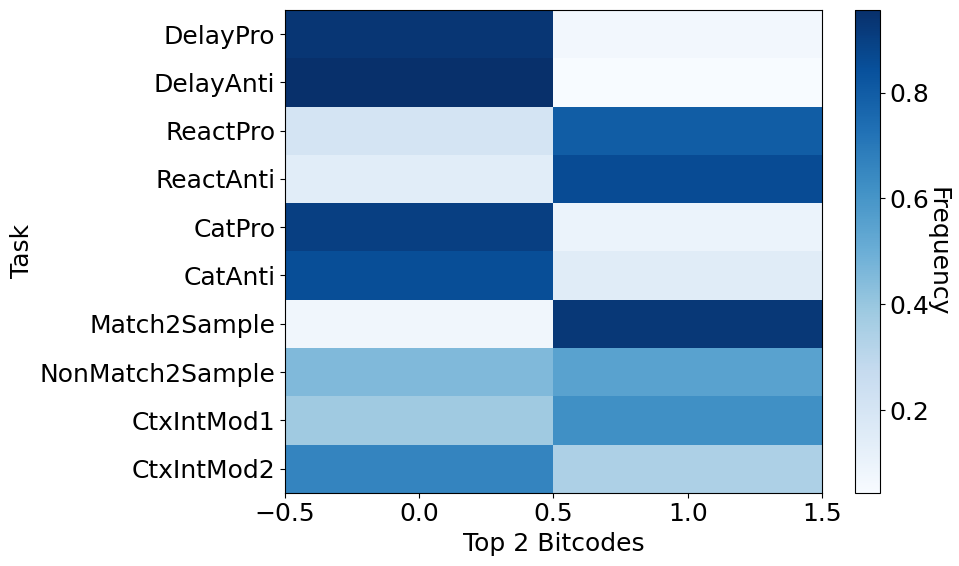

In [ ]:
plt.rcParams['font.size'] = 18
plt.rcParams['lines.linewidth'] = 2.

# Create a simple model object with L attribute for compatibility
class SimpleModel:
    def __init__(self, L):
        self.L = L

model = SimpleModel(model_L)

# Plot bitcode distributions
af.plot_bitcode_distributions(latent_states, model, task_names, aligned_matrix, bitcode_labels, top_k=2)
plt.show()


In [ ]:
# Assuming your matrix is (11, 8)
def compute_similarity_matrix(prob_matrix, metric='js'):
    n = prob_matrix.shape[0]
    sim_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            if metric == 'js':
                # Jensen-Shannon distance (scipy returns sqrt of JS divergence)
                dist = jensenshannon(prob_matrix[i], prob_matrix[j])
            elif metric == 'hellinger':
                dist = np.sqrt(1 - np.sum(np.sqrt(prob_matrix[i] * prob_matrix[j])))
            elif metric == 'bhattacharyya':
                dist = -np.log(np.sum(np.sqrt(prob_matrix[i] * prob_matrix[j])))
            sim_matrix[i, j] = sim_matrix[j, i] = dist
    
    return sim_matrix

In [5]:
from scipy.spatial.distance import jensenshannon
# Or convert distance to similarity
sim_matrix_3_2 = 1-compute_similarity_matrix(aligned_matrix, 'js')

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create annotation labels from sim_matrix_3_2
annot_labels = np.empty_like(sim_matrix_3_2, dtype=object)
for i in range(sim_matrix_3_2.shape[0]):
    for j in range(sim_matrix_3_2.shape[1]):
        if i == j:
            annot_labels[i, j] = ''  # Empty string for diagonal
        else:
            annot_labels[i, j] = f'{sim_matrix_3_2[i, j]:.2f}'

# Hide diagonal
sim_matrix_plot = sim_matrix_3_2.copy()
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    sim_matrix_plot,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=task_names,
    yticklabels=task_names,
    cbar_kws={'label': 'Similarity'},
    mask=np.isnan(sim_matrix_plot),
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title("Similarity Matrix (Bitcode Distributions)", fontsize=14)
ax.set_xlabel("Task")
ax.set_ylabel("Task")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


NameError: name 'sim_matrix_3_2' is not defined

In [14]:
import numpy as np
data = np.load("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\P=1_latent_states.npz")

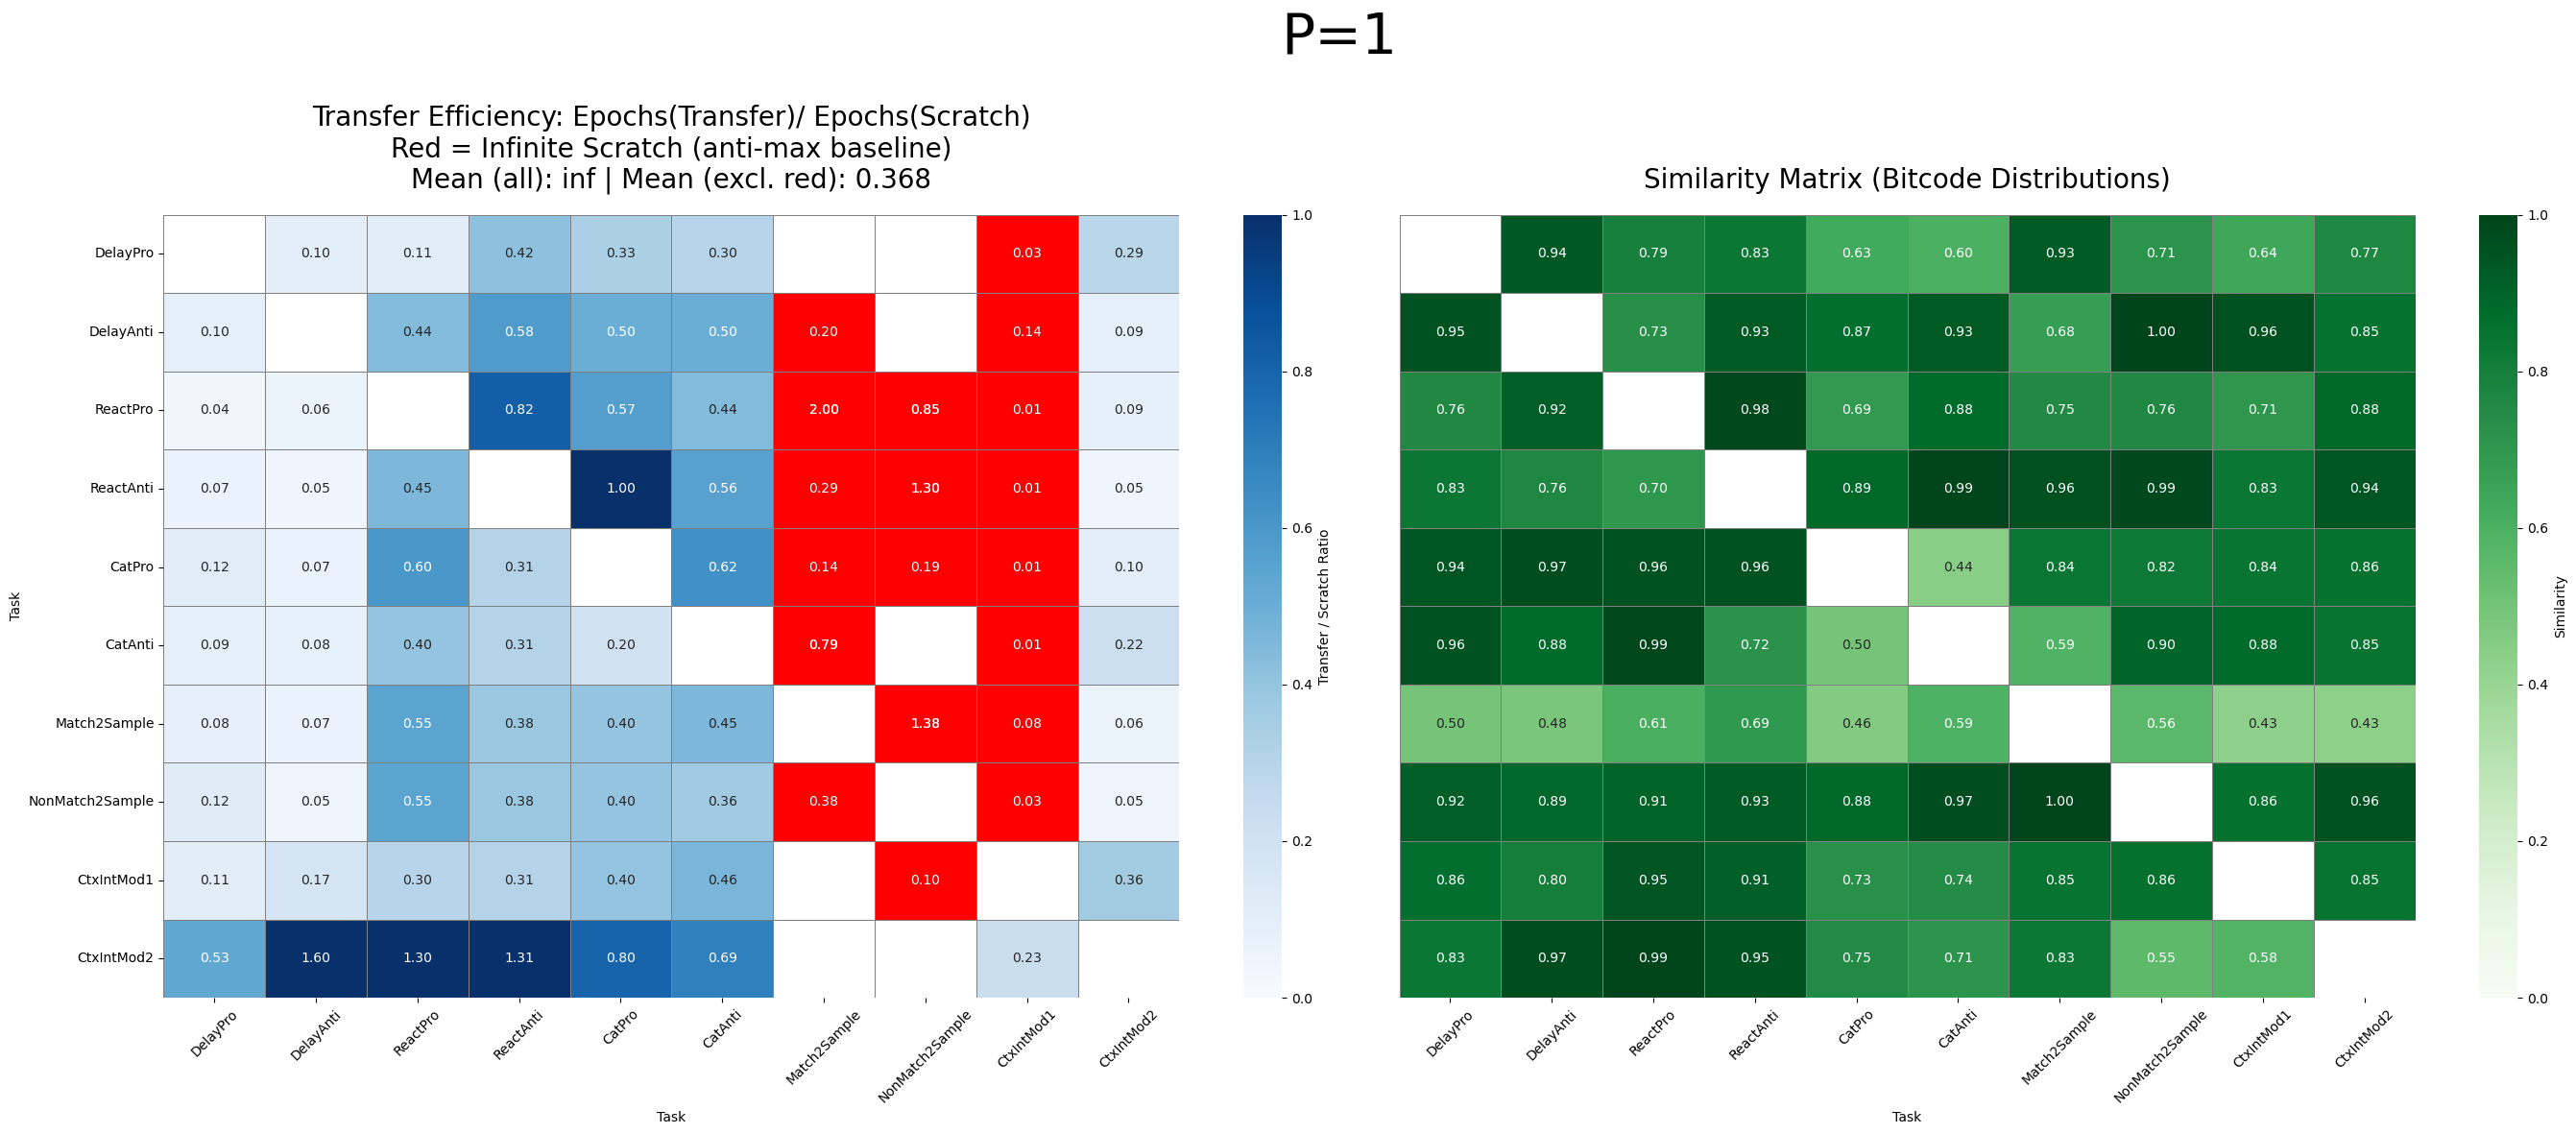

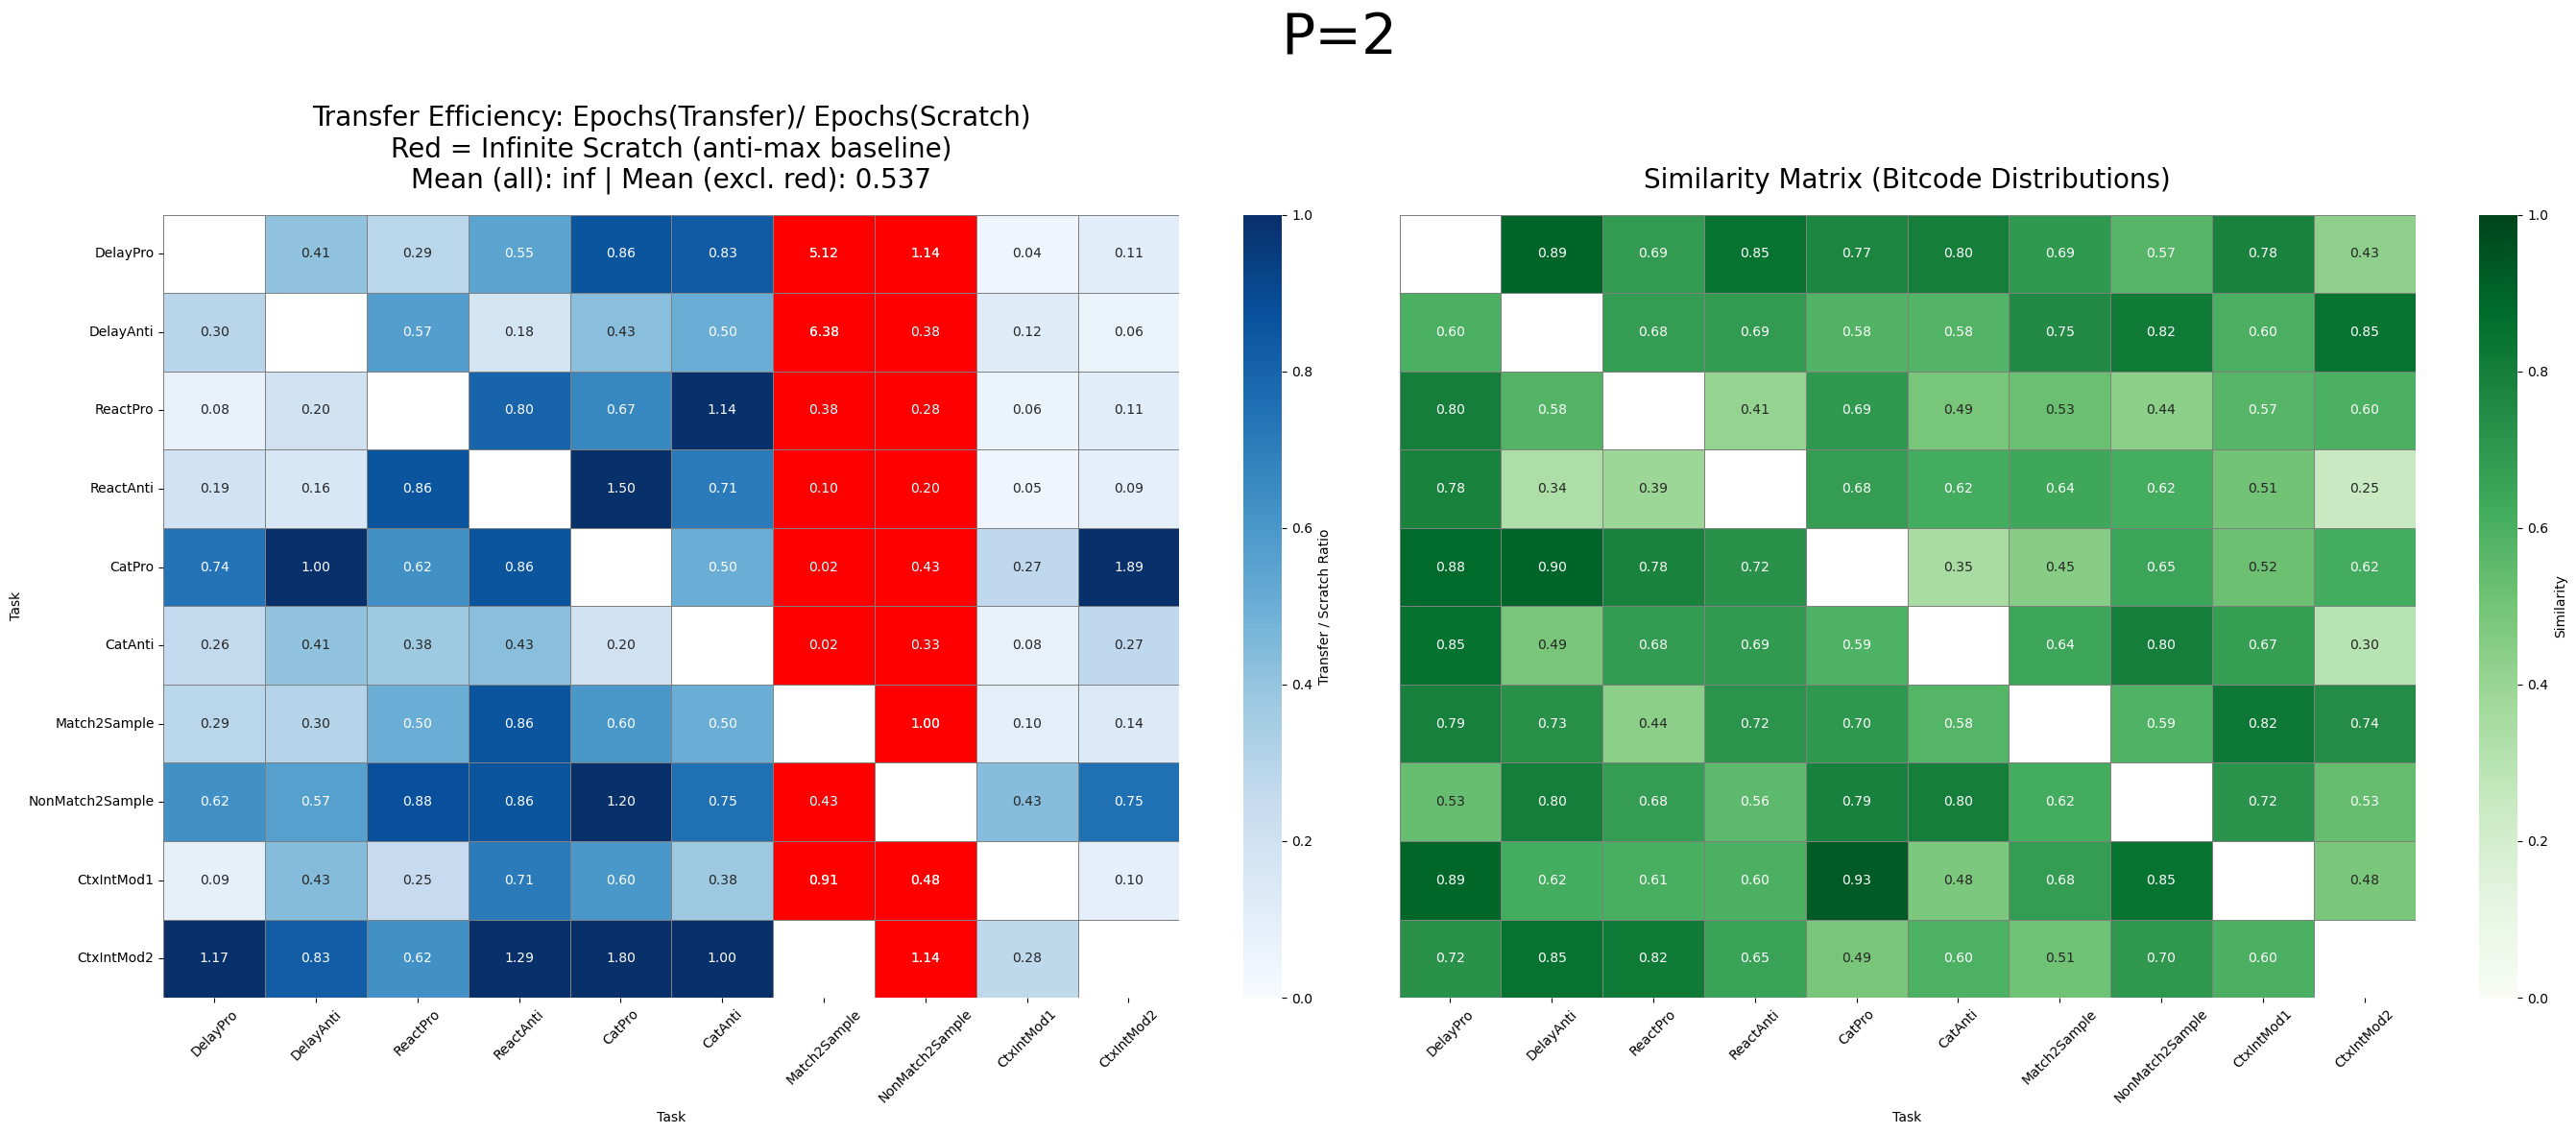

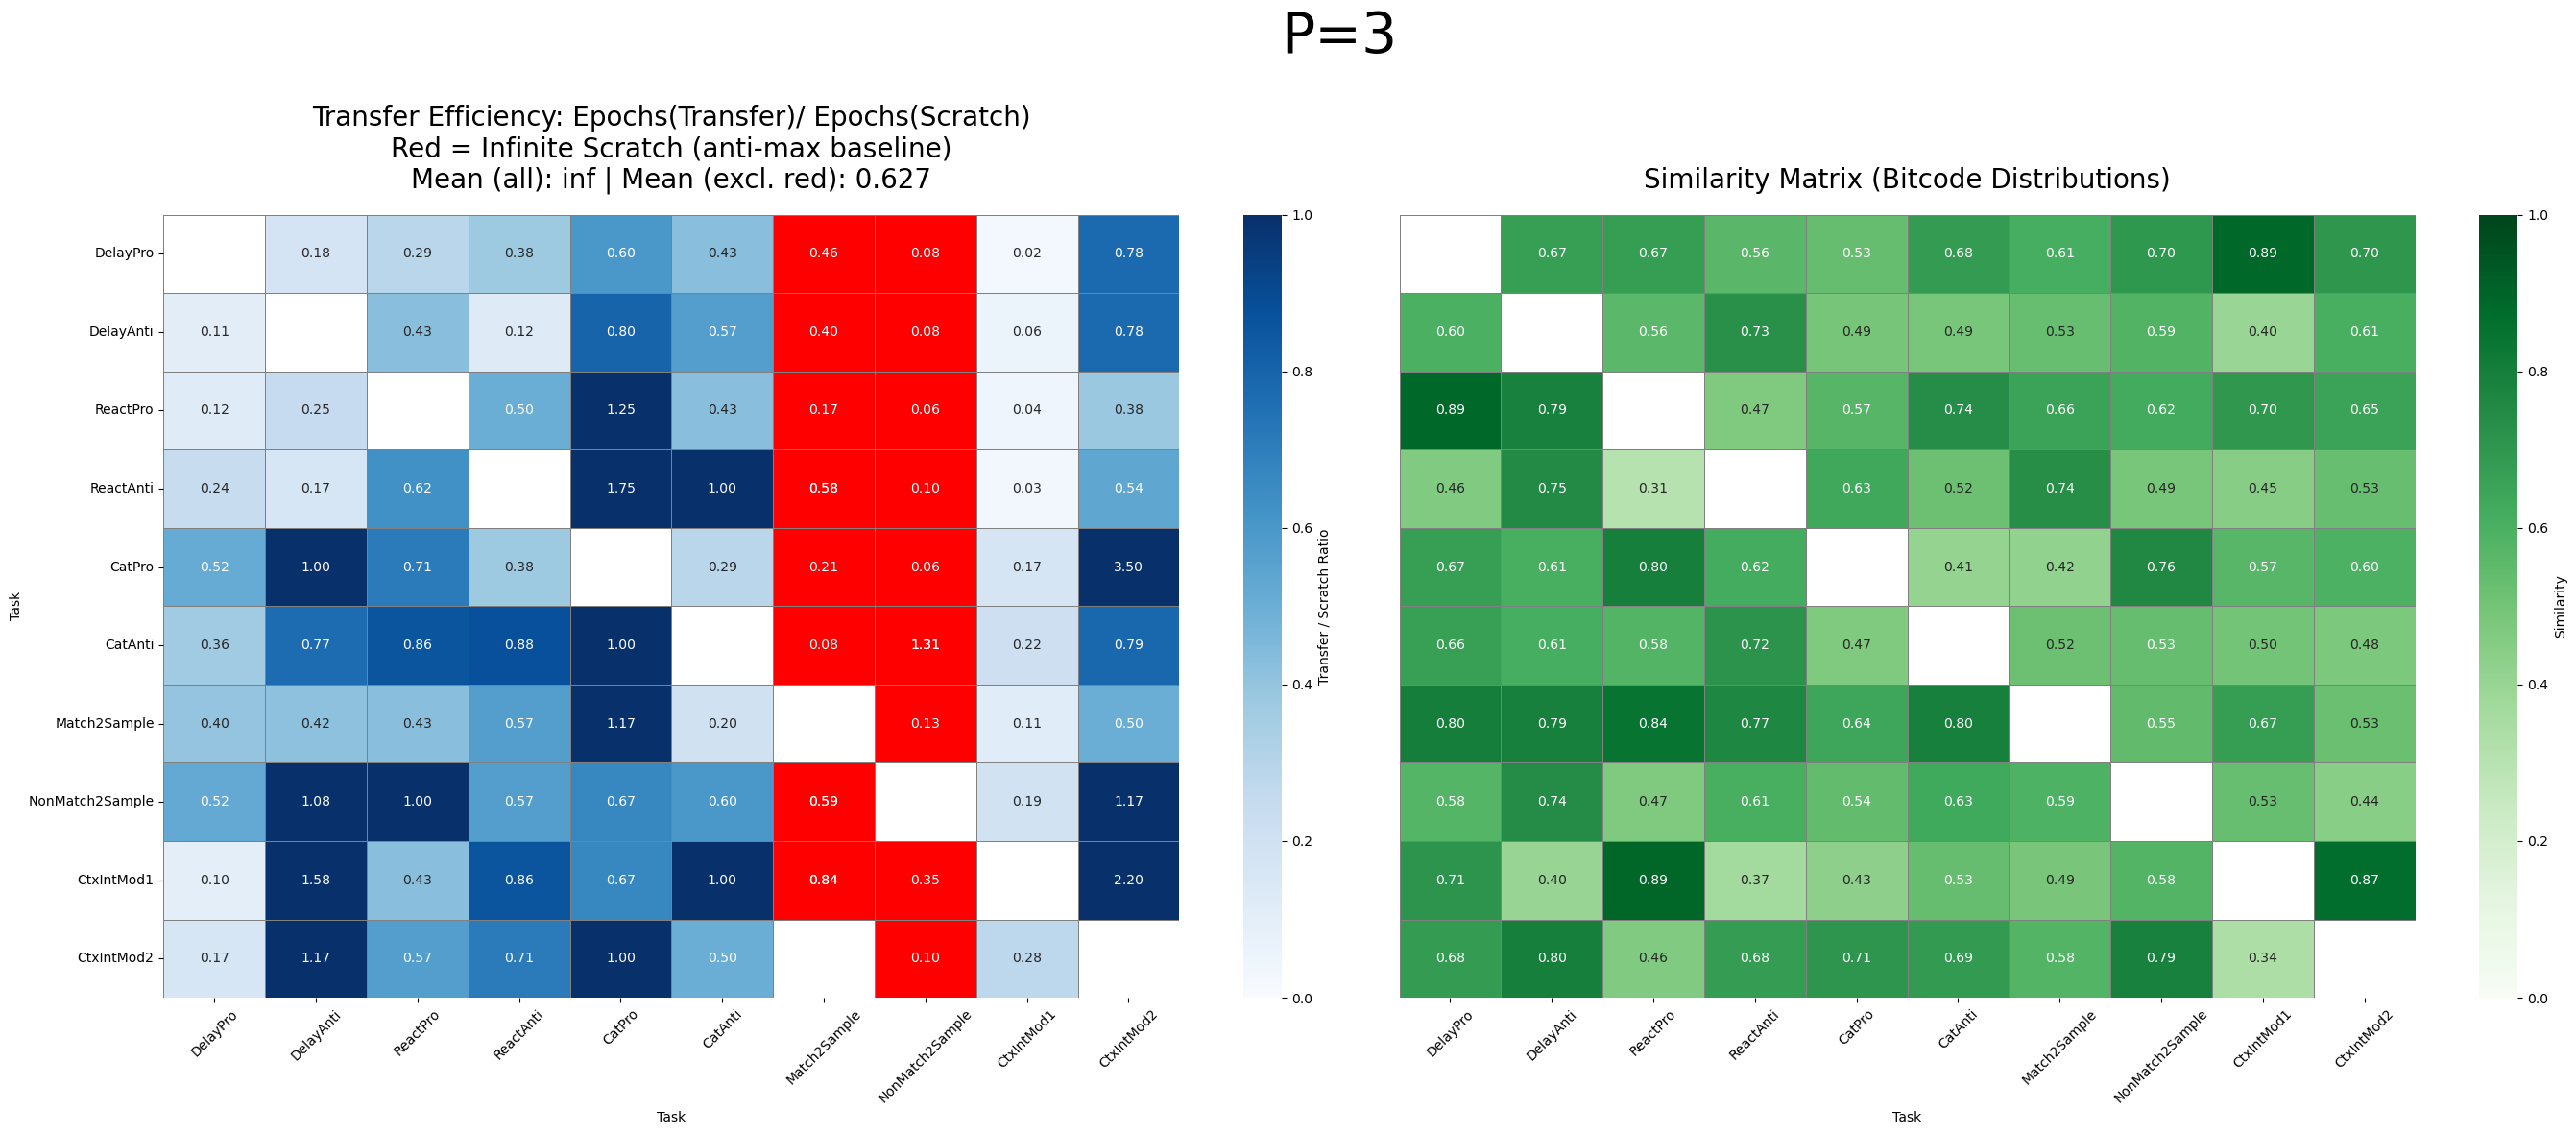

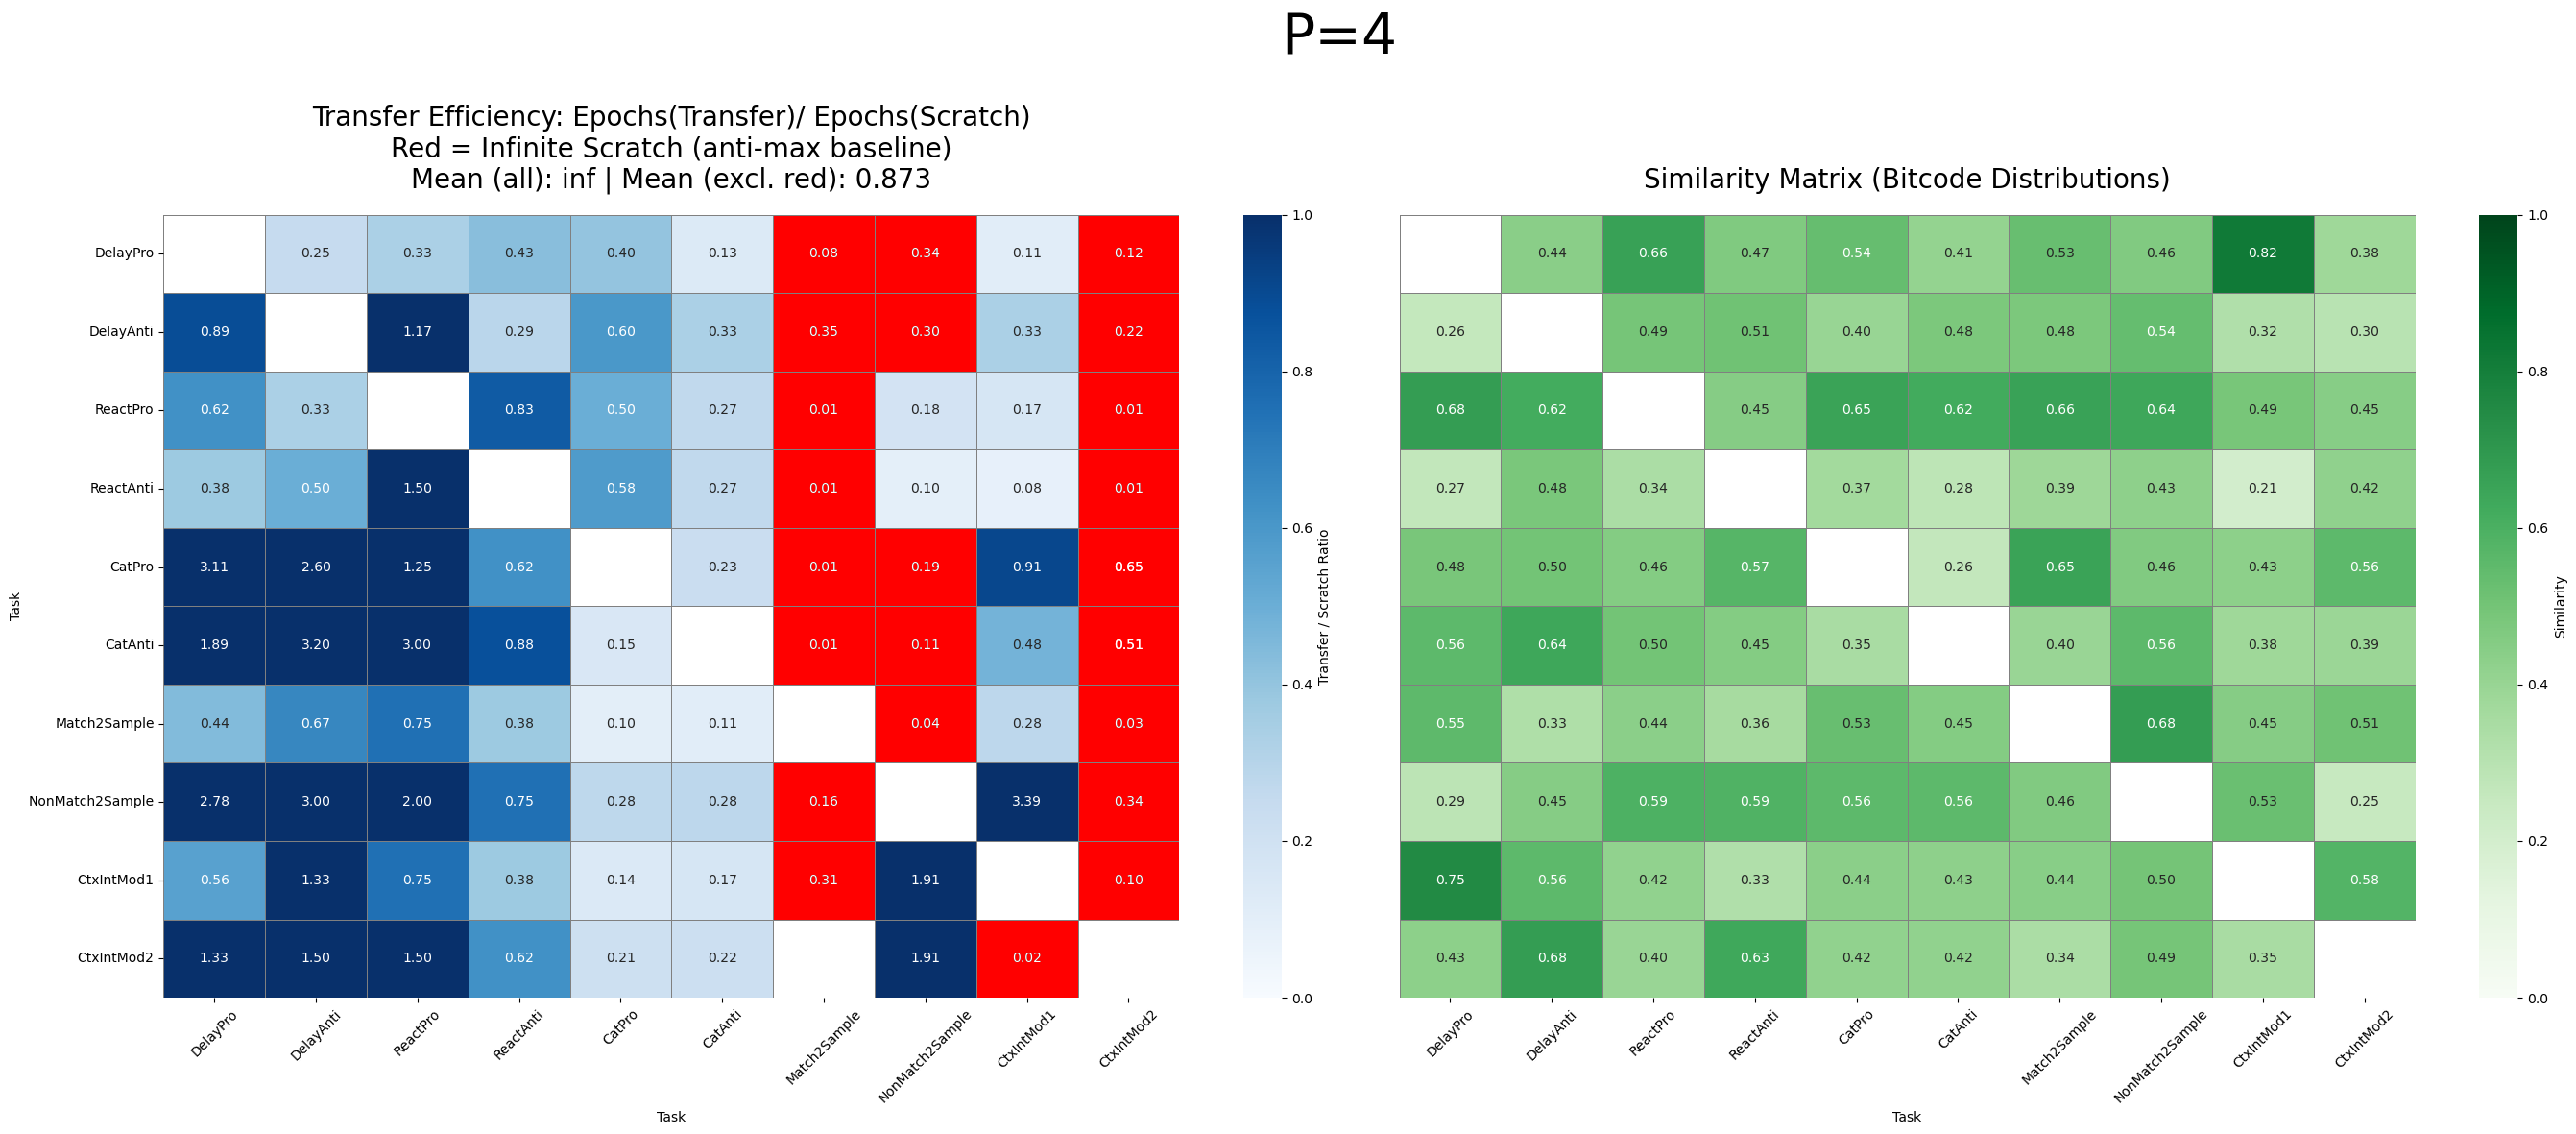

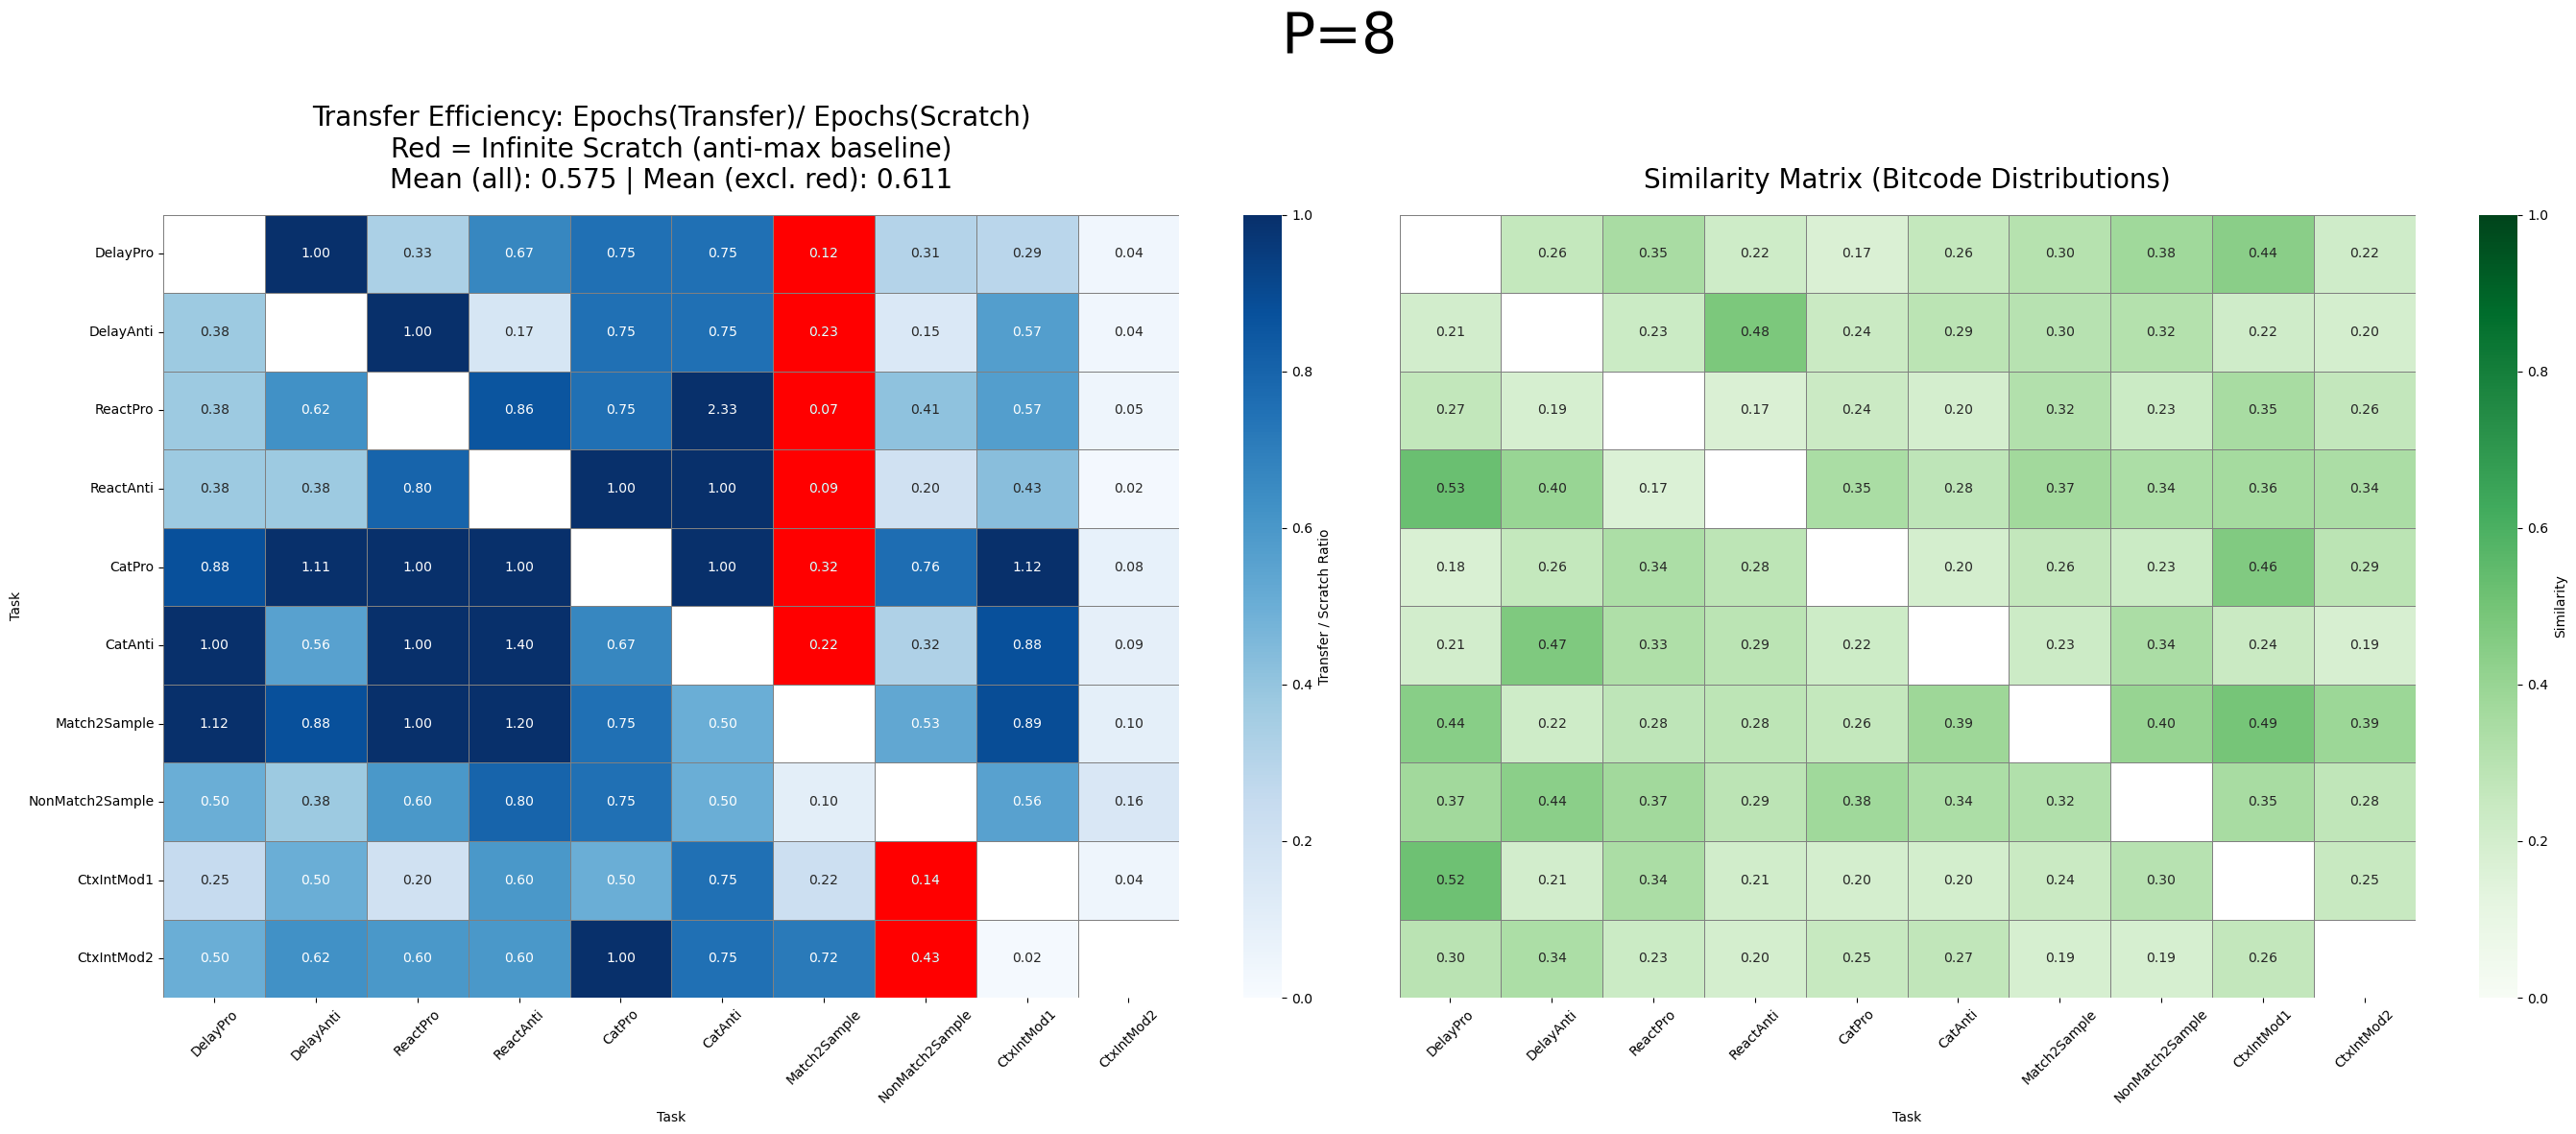

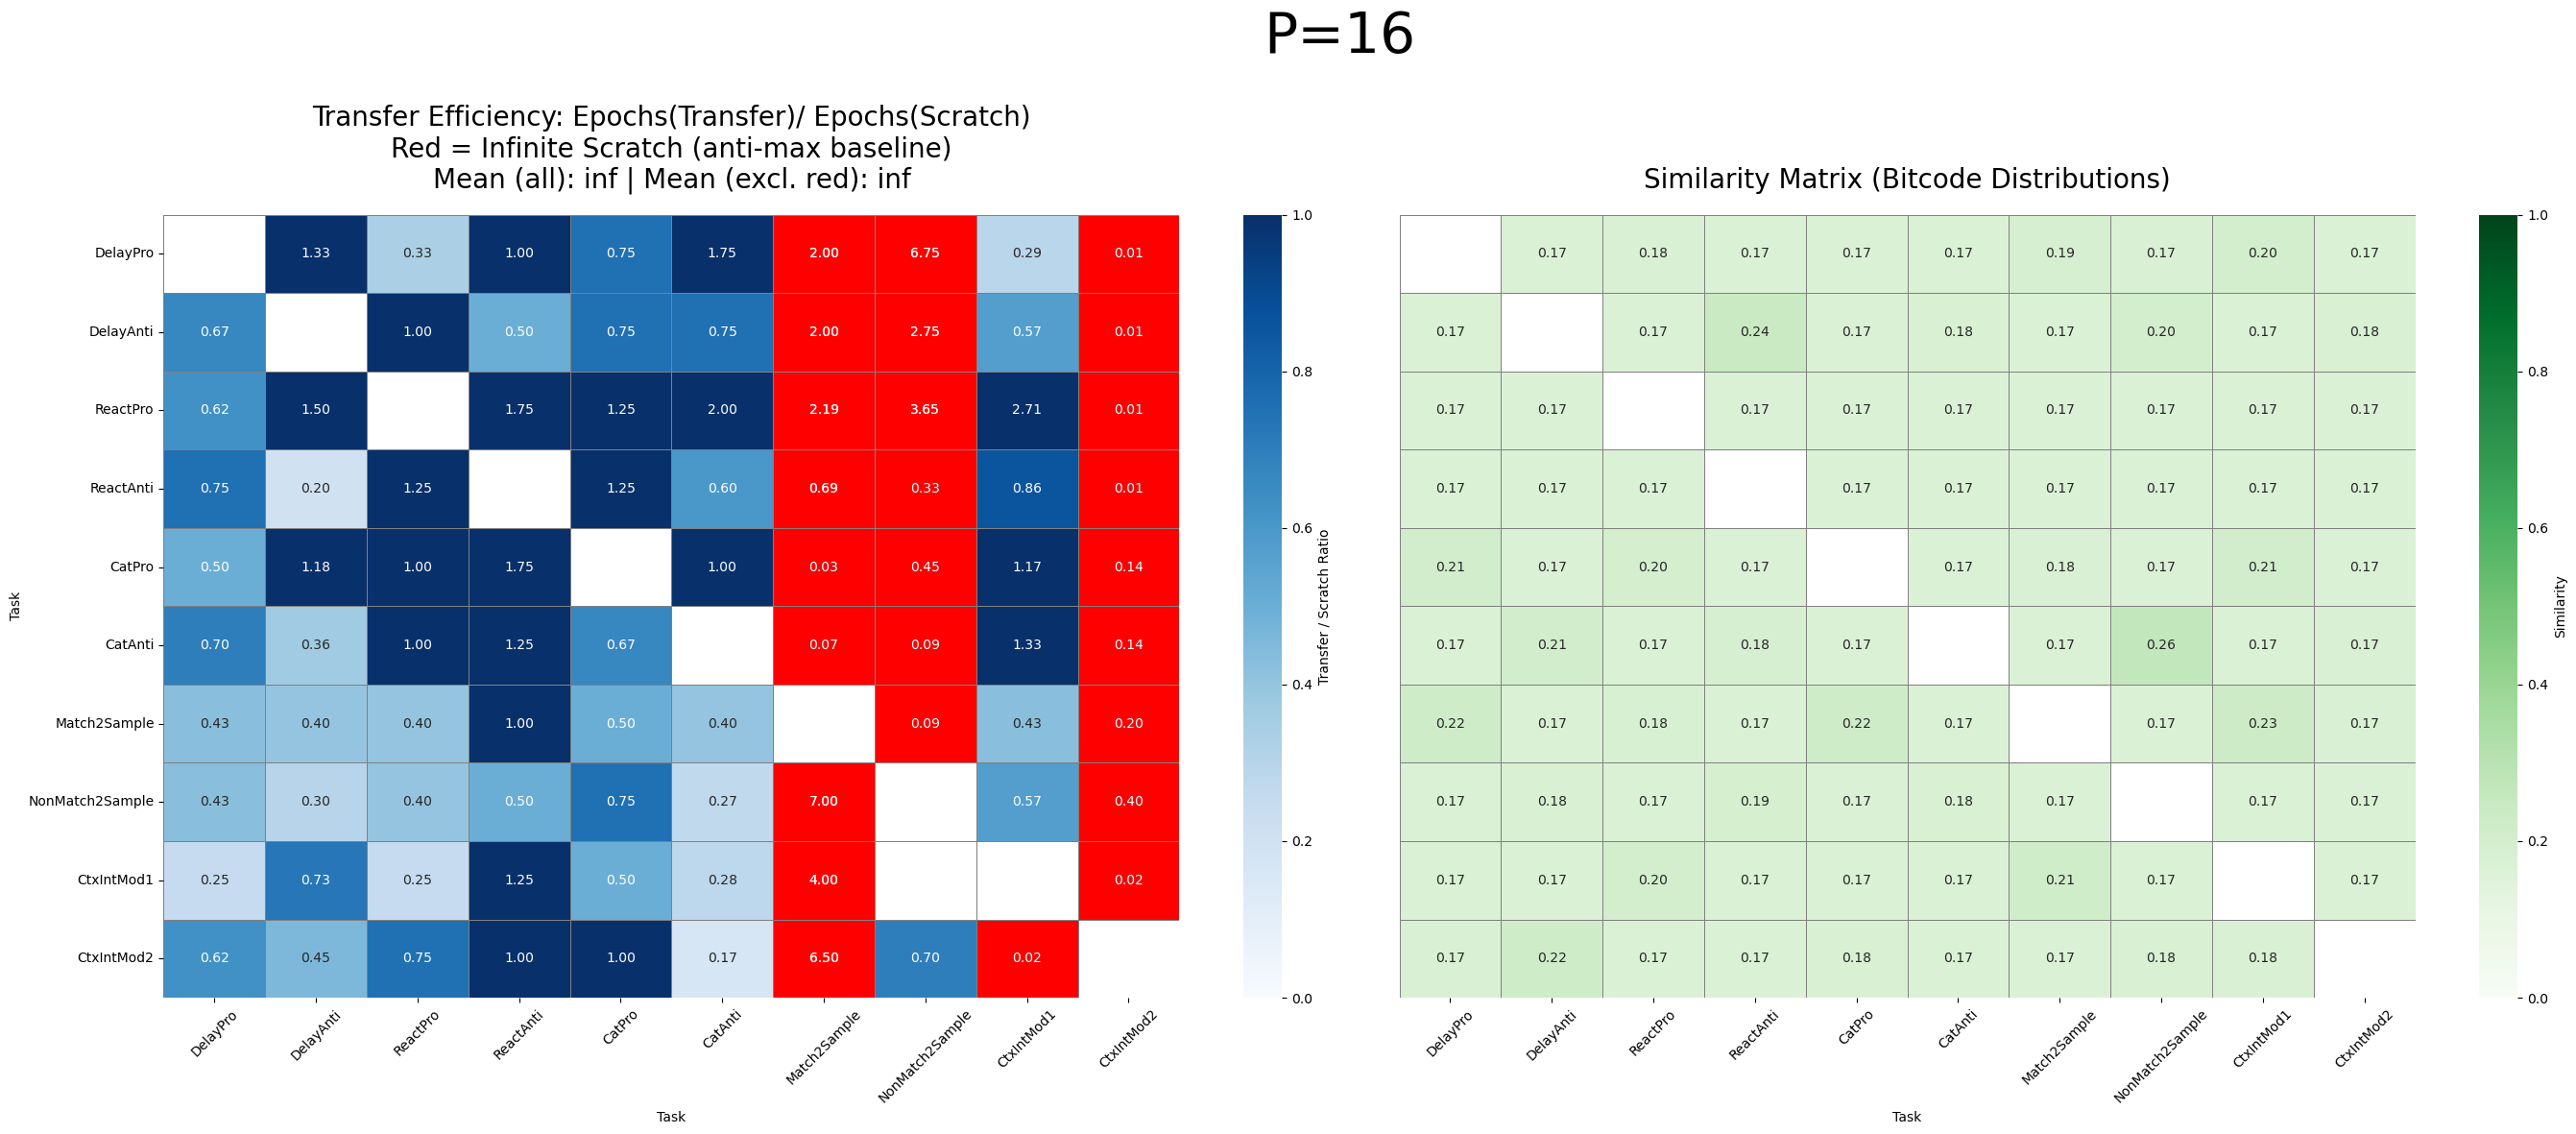

C:\Users\garcias\AppData\Local\Temp\ipykernel_25124\2441330668.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(bp1_data, labels=P_values)
C:\Users\garcias\AppData\Local\Temp\ipykernel_25124\2441330668.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bp2_data, labels=P_values)


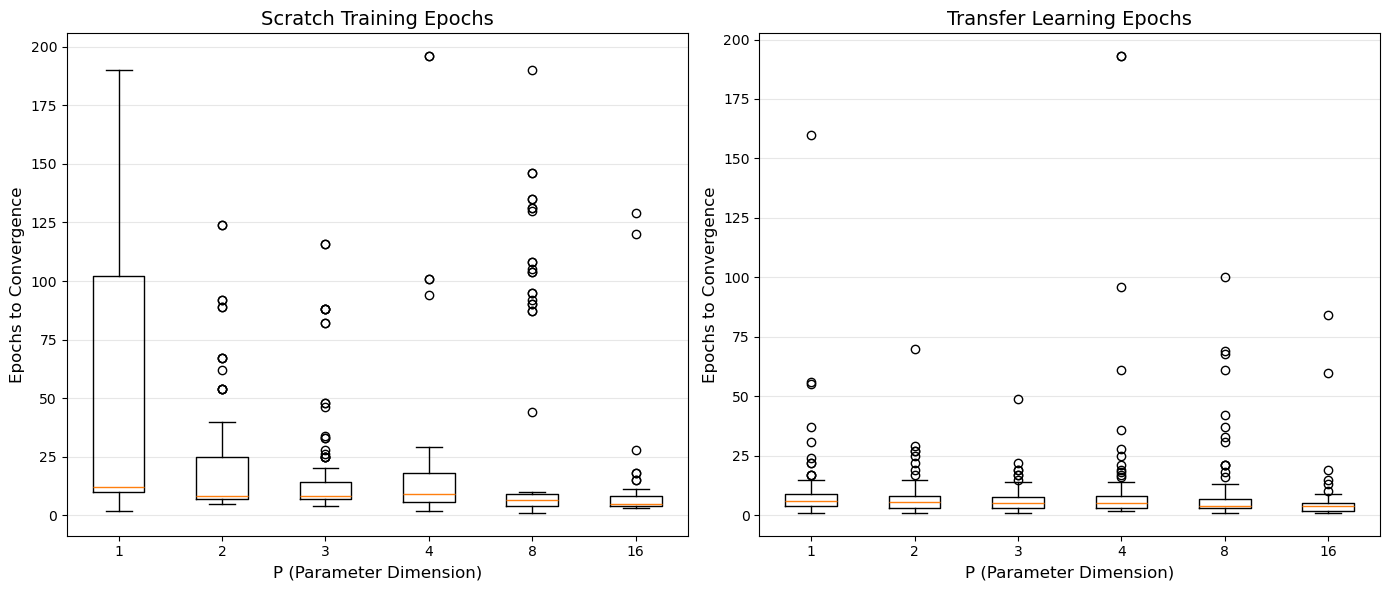

C:\Users\garcias\AppData\Local\Temp\ipykernel_25124\2441330668.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bp3_data, labels=P_values)


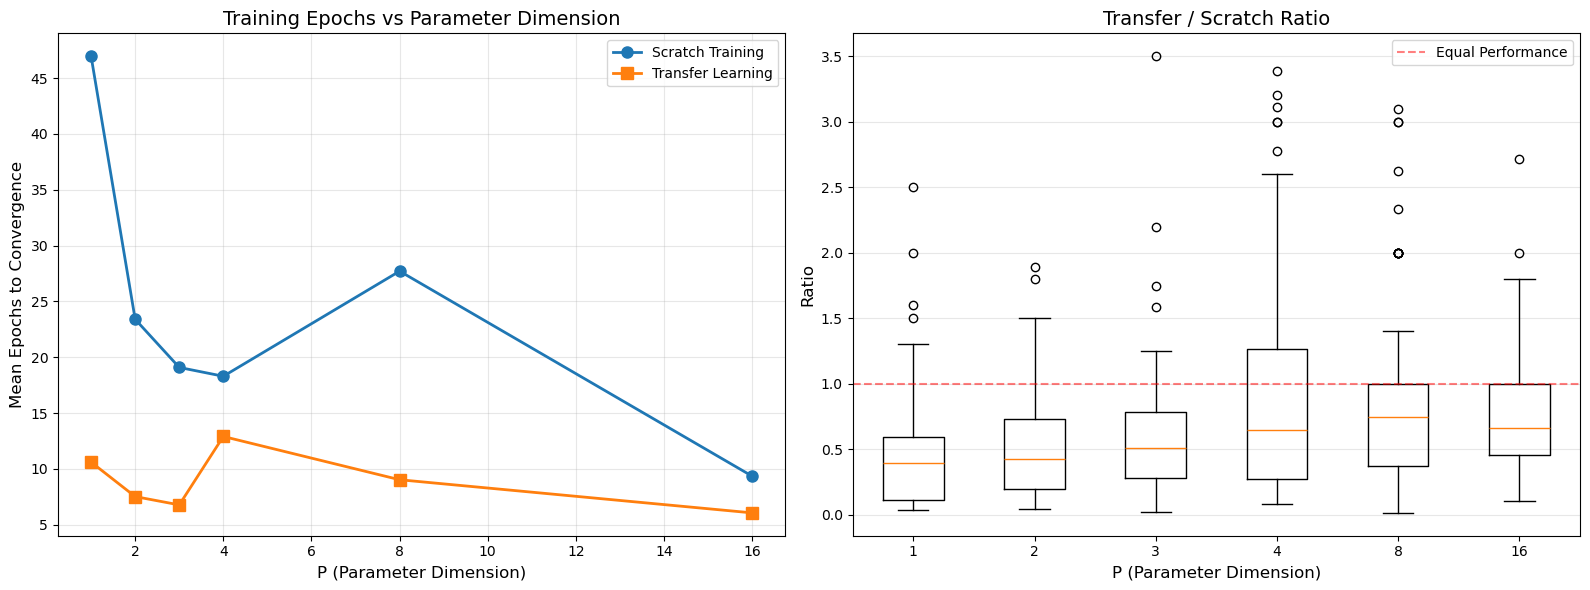

In [1]:
import importlib
import multi_task_training.utils
importlib.reload(multi_task_training.utils)
from multi_task_training.utils import plot_transfer_and_similarity
import numpy as np
import matplotlib.pyplot as plt

P_values = [1, 2, 3, 4, 8, 16]
mean_scratch_by_P = []
mean_transfer_by_P = []
# Store all individual values for boxplots
all_scratch_by_P = {P: [] for P in P_values}
all_transfer_by_P = {P: [] for P in P_values}
all_ratio_by_P = {P: [] for P in P_values}

for P in P_values:

    latent_path = rf"C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\P={P}_latent_states.npz"
    # Consolidated training history is saved by utils.save_training_history under multi_task_training/results
    training_history_path = rf"C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\P={P}_training_history.npz"

    # Use scripts/results as base_path (ignored when training_history_path is provided)
    base_path = r"C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\scripts\\results"

    # Load training history to extract epochs data
    hist_data = np.load(training_history_path, allow_pickle=True)
    
    all_epochs_scratch = []
    all_epochs_transfer = []
    
    for key in hist_data.files:
        entry = hist_data[key].item() if hasattr(hist_data[key], 'item') else hist_data[key]
        if isinstance(entry, dict):
            if 'epochs_to_scratch' in entry and 'epochs_to_transfer' in entry:
                epochs_scratch = entry['epochs_to_scratch']
                epochs_transfer = entry['epochs_to_transfer']
                # Only include cases where both scratch and transfer converged
                if epochs_scratch != np.inf and epochs_transfer != np.inf:
                    all_epochs_scratch.append(epochs_scratch)
                    all_epochs_transfer.append(epochs_transfer)
                    # Store for boxplots
                    all_scratch_by_P[P].append(epochs_scratch)
                    all_transfer_by_P[P].append(epochs_transfer)
                    all_ratio_by_P[P].append(epochs_transfer / epochs_scratch)
    
    hist_data.close()
    
    # Compute averages
    mean_epochs_scratch = np.mean(all_epochs_scratch) if all_epochs_scratch else np.nan
    mean_epochs_transfer = np.mean(all_epochs_transfer) if all_epochs_transfer else np.nan
    
    mean_scratch_by_P.append(mean_epochs_scratch)
    mean_transfer_by_P.append(mean_epochs_transfer)

    (fig, (ax1, ax2)), matrix, sim_matrix_3_2 = plot_transfer_and_similarity(
        base_path=base_path,
        latent_path=latent_path,
        training_history_path=training_history_path,
        similarity_cmap="Greens",
        suptitle=f"P={P}",
        suptitle_size=42,
    )
    fig.clear()

# Create boxplots for scratch and transfer epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: Epochs to Scratch
bp1_data = [all_scratch_by_P[P] for P in P_values]
axes[0].boxplot(bp1_data, labels=P_values)
axes[0].set_xlabel('P (Parameter Dimension)', fontsize=12)
axes[0].set_ylabel('Epochs to Convergence', fontsize=12)
axes[0].set_title('Scratch Training Epochs', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Boxplot 2: Epochs to Transfer
bp2_data = [all_transfer_by_P[P] for P in P_values]
axes[1].boxplot(bp2_data, labels=P_values)
axes[1].set_xlabel('P (Parameter Dimension)', fontsize=12)
axes[1].set_ylabel('Epochs to Convergence', fontsize=12)
axes[1].set_title('Transfer Learning Epochs', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Create combined figure: line plot + ratio boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Line plot for mean epochs
axes[0].plot(P_values, mean_scratch_by_P, marker='o', linewidth=2, markersize=8, label='Scratch Training')
axes[0].plot(P_values, mean_transfer_by_P, marker='s', linewidth=2, markersize=8, label='Transfer Learning')
axes[0].set_xlabel('P (Parameter Dimension)', fontsize=12)
axes[0].set_ylabel('Mean Epochs to Convergence', fontsize=12)
axes[0].set_title('Training Epochs vs Parameter Dimension', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right plot: Transfer / Scratch Ratio boxplot
bp3_data = [all_ratio_by_P[P] for P in P_values]
axes[1].boxplot(bp3_data, labels=P_values)
axes[1].set_xlabel('P (Parameter Dimension)', fontsize=12)
axes[1].set_ylabel('Ratio', fontsize=12)
axes[1].set_title('Transfer / Scratch Ratio', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Equal Performance')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

#W matrix of 16x16 instead of 32x32

In [ ]:
import numpy as np
data = np.load("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\PvsTrials\\P=1_training_history.npz", allow_pickle=True)

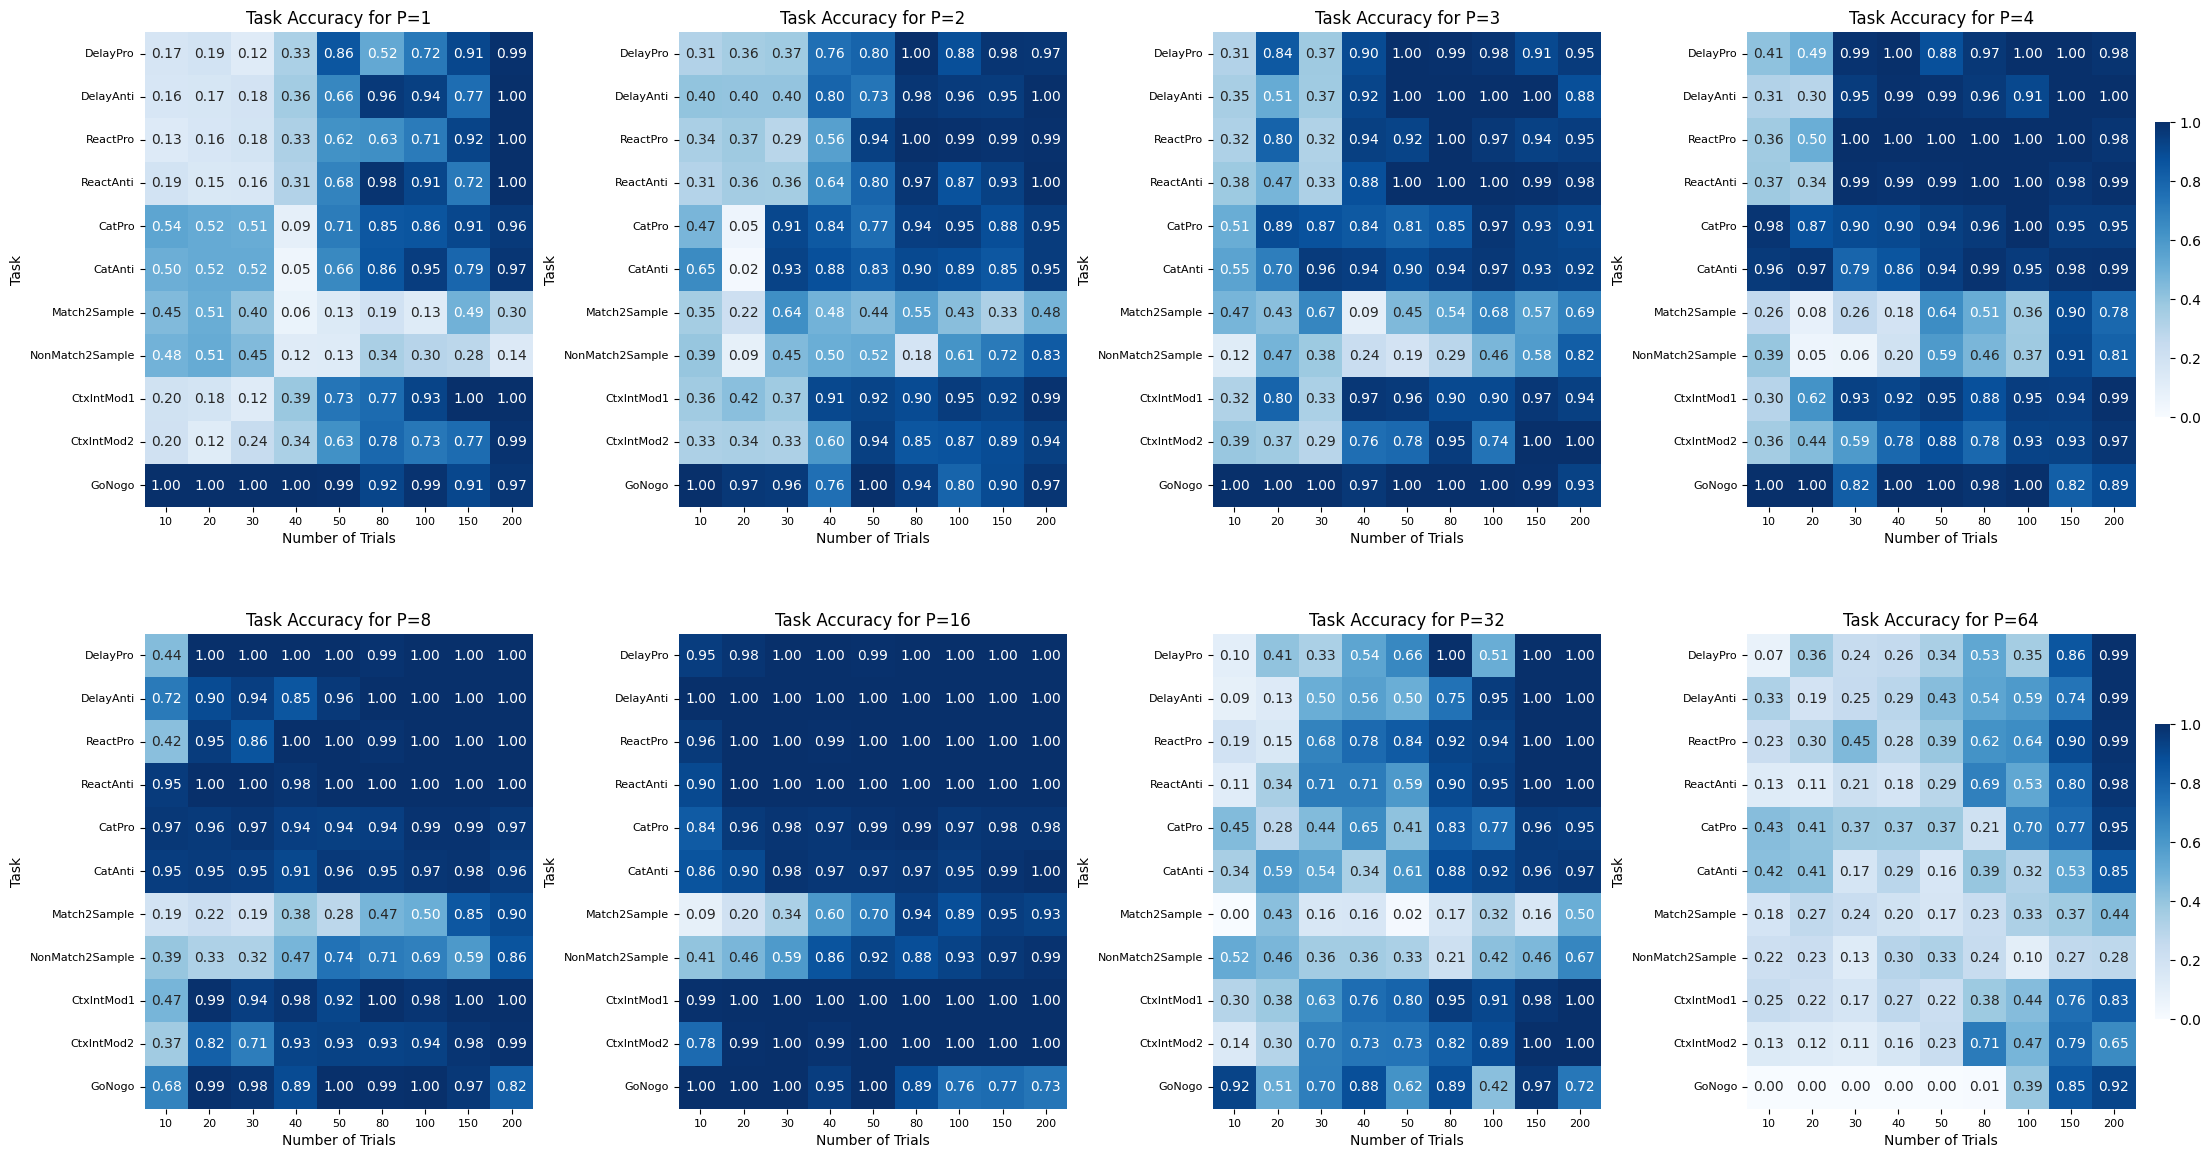

Saved combined heatmap -> C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\results\PvsTrials\all_P_heatmaps.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

"""Plot heatmaps for P vs Trials using best_test_accuracies stored in NPZ files.

For every file in ../results/PvsTrials matching '*_training_history.npz' this script
loads the file, extracts keys like 'trials=10_P=1', reads the entry's
`best_test_accuracies` (expected to be a mapping from task index -> accuracy), and
builds a heatmap where x axis are trial values (sorted), y axis are the fixed task
names in the requested order, and values are per-task best test accuracies.

Saves one PNG per P value in the same PvsTrials folder: 'P=<P>_heatmap.png'.
"""

TASK_NAMES = [
    "DelayPro", "DelayAnti", 'ReactPro', 'ReactAnti',
    'CatPro', 'CatAnti','Match2Sample', 'NonMatch2Sample',
    'CtxIntMod1', 'CtxIntMod2', 'GoNogo'
]


def load_file(filepath):
    try:
        data = dict(np.load(filepath, allow_pickle=True))
    except Exception as e:
        raise RuntimeError(f"Failed to load {filepath}: {e}")
    return data


def parse_key(key):
    # Expect format 'trials=<n>_P=<p>' (but be tolerant)
    parts = key.split("_")
    trials = None
    P = None
    for part in parts:
        if part.startswith("trials="):
            try:
                trials = int(part.split("=", 1)[1])
            except Exception:
                pass
        if part.startswith("P="):
            try:
                P = int(part.split("=", 1)[1])
            except Exception:
                pass
    return trials, P


def best_test_array_from_entry(entry, n_tasks=len(TASK_NAMES)):
    """Extract per-task best_test_accuracies from an entry's best_test_accuracies field.

    The saved value can be:
    - a dict mapping integers (0..n-1) -> floats,
    - an array-like sequence of length n_tasks,
    - or other pickled containers.

    Returns a numpy array length n_tasks with floats or np.nan for missing.
    """
    if entry is None:
        return np.full((n_tasks,), np.nan)

    # If it's an np.ndarray or list-like
    try:
        if isinstance(entry, (np.ndarray, list, tuple)):
            arr = np.asarray(entry)
            if arr.size == n_tasks:
                return arr.astype(float)
            # If it's 1D shorter/longer, try to map first n_tasks
            out = np.full((n_tasks,), np.nan)
            out[: min(n_tasks, arr.size)] = arr[:min(n_tasks, arr.size)]
            return out
    except Exception:
        pass

    # If it's a dict-like mapping
    try:
        d = dict(entry)
        out = np.full((n_tasks,), np.nan)
        for k, v in d.items():
            # ignore reserved keys if present
            if isinstance(k, str) and k.startswith("_"):
                continue
            try:
                idx = int(k)
            except Exception:
                # sometimes keys are stored as int in numpy object arrays
                continue
            if 0 <= idx < n_tasks:
                out[idx] = float(v)
        return out
    except Exception:
        pass

    # Fallback: try to coerce to float
    try:
        scalar = float(entry)
        return np.full((n_tasks,), scalar)
    except Exception:
        return np.full((n_tasks,), np.nan)


def plot_heatmap(matrix, x_labels, y_labels, title, outpath):
    n_rows, n_cols = matrix.shape
    
    # Calculate figure size to make cells square
    cell_size = 0.5  # Reduced size for smaller figure
    fig_width = n_cols * cell_size + 2  # Add margin for labels
    fig_height = n_rows * cell_size + 1.5  # Add margin for labels
    
    plt.figure(figsize=(fig_width, fig_height))
    ax = sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
                     xticklabels=x_labels, yticklabels=y_labels, 
                     vmin=0.0, vmax=1.0, square=True,
                     cbar_kws={'shrink': 0.5})  # Shrink colorbar to 50% of plot height
    ax.set_xlabel('Number of Trials')
    ax.set_ylabel('Task')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def extract_p_from_filename(filepath):
    fname = os.path.basename(filepath)
    if fname.startswith('P='):
        try:
            return int(fname.split('_', 1)[0].split('=')[1])
        except Exception:
            return float('inf')  # Put unparseable files at the end
    return float('inf')


def main(pvs_dir=None):
    if pvs_dir is None:
        base = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
        pvs_dir = os.path.join(base, 'results', 'PvsTrials')

    if not os.path.exists(pvs_dir):
        raise FileNotFoundError(pvs_dir)

    # Find training_history npz files
    files = [os.path.join(pvs_dir, f) for f in os.listdir(pvs_dir) if f.endswith('_training_history.npz')]
    if not files:
        print(f"No '*_training_history.npz' files found in {pvs_dir}")
        return

    # Sort files by P value
    def extract_p_from_filename(filepath):
        fname = os.path.basename(filepath)
        if fname.startswith('P='):
            try:
                return int(fname.split('_', 1)[0].split('=')[1])
            except Exception:
                return float('inf')
        return float('inf')

    files_sorted = sorted(files, key=extract_p_from_filename)

    # Collect all data first
    all_data = []
    for filepath in files_sorted:
        data = load_file(filepath)

        records = []
        for key_bytes, value in data.items():
            key = key_bytes.decode('utf-8') if isinstance(key_bytes, bytes) else str(key_bytes)
            trials, P = parse_key(key)
            if trials is None:
                continue

            try:
                entry = value.item() if hasattr(value, 'item') else value
            except Exception:
                entry = value

            best = None
            if isinstance(entry, dict):
                if 'best_test_accuracies' in entry:
                    best = entry['best_test_accuracies']
                elif 'best_test_accuracy' in entry:
                    best = entry['best_test_accuracy']
                else:
                    best = entry
            else:
                best = entry

            arr = best_test_array_from_entry(best, n_tasks=len(TASK_NAMES))
            records.append((trials, arr, P))

        if not records:
            print(f"No records parsed from {filepath}")
            continue

        # Determine P for this file
        fname = os.path.basename(filepath)
        P_from_name = None
        if fname.startswith('P='):
            try:
                P_from_name = int(fname.split('_', 1)[0].split('=')[1])
            except Exception:
                P_from_name = None

        P_values = set([r[2] for r in records if r[2] is not None])
        P_val = P_from_name if P_from_name is not None else (list(P_values)[0] if P_values else 'unknown')

        records.sort(key=lambda x: x[0])
        trials_list = [r[0] for r in records]
        matrix = np.stack([r[1] for r in records], axis=1)

        all_data.append((P_val, matrix, trials_list))

    # Create a single figure with 2 rows and 4 columns using constrained_layout
    fig, axes = plt.subplots(2, 4, figsize=(22, 12), constrained_layout=True)
    axes = axes.flatten()

    for idx, (P_val, matrix, trials_list) in enumerate(all_data):
        if idx >= 8:
            break
        
        ax = axes[idx]
        # Show colorbar only at the end of each row (idx 3 and 7)
        show_cbar = (idx == 3 or idx == 7)
        
        sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=trials_list, yticklabels=TASK_NAMES,
                   vmin=0.0, vmax=1.0, square=True,
                   cbar=show_cbar, 
                   cbar_kws={'shrink': 0.5}, 
                   ax=ax)
        ax.set_xlabel('Number of Trials', fontsize=10)
        ax.set_ylabel('Task', fontsize=10)
        ax.set_title(f'Task Accuracy for P={P_val}', fontsize=12)
        ax.tick_params(labelsize=8)

    outpath = os.path.join(pvs_dir, 'all_P_heatmaps.png')
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved combined heatmap -> {outpath}")
main("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\PvsTrials")

Found trials: [10, 20, 30, 40, 50, 80, 100, 150, 200]
Found P values: [1, 2, 3, 4, 8, 16, 32, 64]


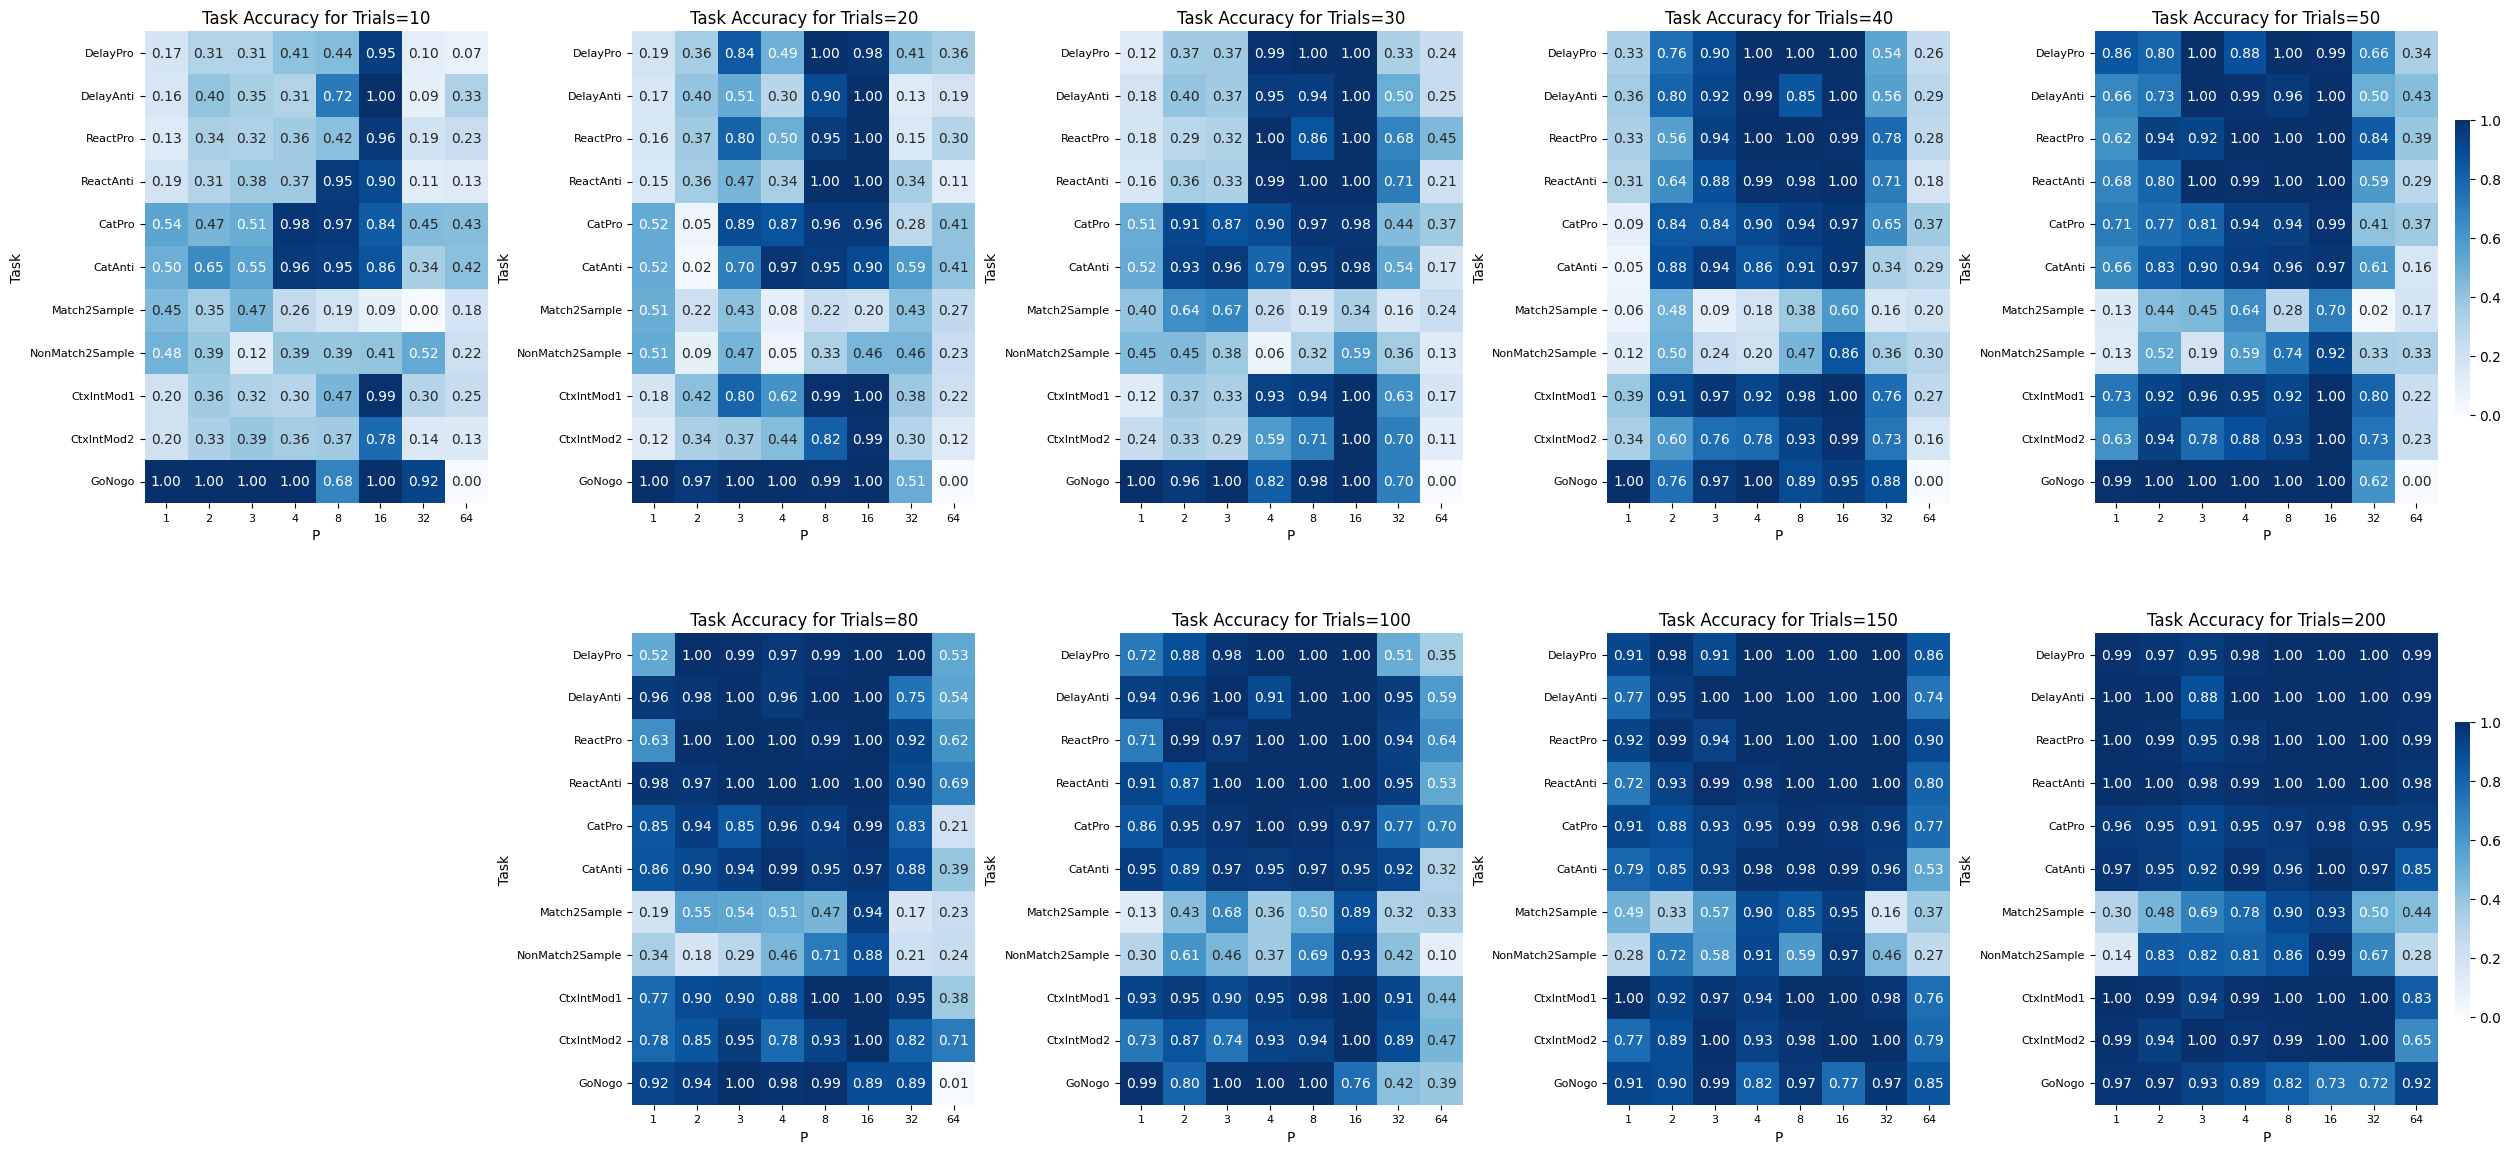

Saved combined heatmap -> C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\results\PvsTrials\all_trials_heatmaps.png


In [16]:
def main(pvs_dir=None):
    if pvs_dir is None:
        base = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
        pvs_dir = os.path.join(base, 'results', 'PvsTrials')

    if not os.path.exists(pvs_dir):
        raise FileNotFoundError(pvs_dir)

    # Find training_history npz files
    files = [os.path.join(pvs_dir, f) for f in os.listdir(pvs_dir) if f.endswith('_training_history.npz')]
    if not files:
        print(f"No '*_training_history.npz' files found in {pvs_dir}")
        return

    # Collect all data organized by (trials, P) -> task_accuracies
    data_dict = {}  # {(trials, P): task_accuracies_array}
    
    for filepath in files:
        data = load_file(filepath)

        for key_bytes, value in data.items():
            key = key_bytes.decode('utf-8') if isinstance(key_bytes, bytes) else str(key_bytes)
            trials, P = parse_key(key)
            if trials is None or P is None:
                continue

            try:
                entry = value.item() if hasattr(value, 'item') else value
            except Exception:
                entry = value

            best = None
            if isinstance(entry, dict):
                if 'best_test_accuracies' in entry:
                    best = entry['best_test_accuracies']
                elif 'best_test_accuracy' in entry:
                    best = entry['best_test_accuracy']
                else:
                    best = entry
            else:
                best = entry

            arr = best_test_array_from_entry(best, n_tasks=len(TASK_NAMES))
            data_dict[(trials, P)] = arr

    if not data_dict:
        print("No data found")
        return

    # Get unique trials and P values, sorted
    all_trials = sorted(set(t for t, p in data_dict.keys()))
    all_P = sorted(set(p for t, p in data_dict.keys()))

    print(f"Found trials: {all_trials}")
    print(f"Found P values: {all_P}")

    # Organize data by trials (one plot per trials value)
    trials_data = []
    for trials in all_trials:
        # Build matrix: rows = tasks, columns = P values
        matrix = []
        for P in all_P:
            if (trials, P) in data_dict:
                matrix.append(data_dict[(trials, P)])
            else:
                matrix.append(np.full((len(TASK_NAMES),), np.nan))
        
        matrix = np.stack(matrix, axis=1)  # shape: (n_tasks, n_P_values)
        trials_data.append((trials, matrix))

    # Create figure with 3 rows and 5 columns - middle row will have the 4 plots centered
    fig, axes = plt.subplots(2, 5, figsize=(25, 12), constrained_layout=True)
    
    # Plot first 5 in the first row
    for idx in range(5):
        if idx >= len(trials_data):
            break
        trials, matrix = trials_data[idx]
        ax = axes[0, idx]
        show_cbar = (idx == 4)  # Show colorbar at end of first row
        
        sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=all_P, yticklabels=TASK_NAMES,
                   vmin=0.0, vmax=1.0, square=True,
                   cbar=show_cbar, 
                   cbar_kws={'shrink': 0.5}, 
                   ax=ax)
        ax.set_xlabel('P', fontsize=10)
        ax.set_ylabel('Task', fontsize=10)
        ax.set_title(f'Task Accuracy for Trials={trials}', fontsize=12)
        ax.tick_params(labelsize=8)
    
    # Hide first subplot in second row for centering
    axes[1, 0].axis('off')
    
    # Plot remaining 4 in the second row (positions 1-4), centered
    for idx in range(4):
        data_idx = idx + 5
        if data_idx >= len(trials_data):
            break
        trials, matrix = trials_data[data_idx]
        ax = axes[1, idx + 1]  # Start from position 1 in second row
        show_cbar = (idx == 3)  # Show colorbar at end of second row
        
        sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=all_P, yticklabels=TASK_NAMES,
                   vmin=0.0, vmax=1.0, square=True,
                   cbar=show_cbar, 
                   cbar_kws={'shrink': 0.5}, 
                   ax=ax)
        ax.set_xlabel('P', fontsize=10)
        ax.set_ylabel('Task', fontsize=10)
        ax.set_title(f'Task Accuracy for Trials={trials}', fontsize=12)
        ax.tick_params(labelsize=8)

    outpath = os.path.join(pvs_dir, 'all_trials_heatmaps.png')
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved combined heatmap -> {outpath}")

main("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\PvsTrials")

Found trials: [10, 20, 30, 40, 50, 80, 100, 150, 200]
Found P values: [64, 32, 16, 8, 4, 3, 2, 1]


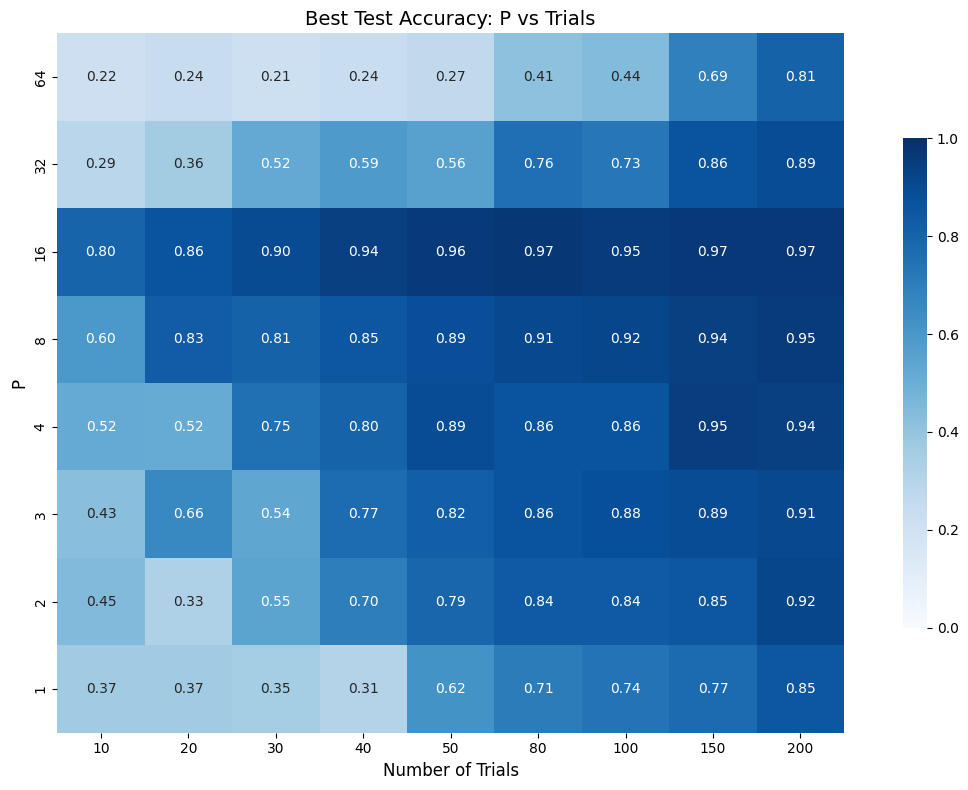

Saved P vs Trials heatmap -> C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\results\PvsTrials\P_vs_trials_heatmap.png


In [9]:
def plot_trials_vs_p_heatmap(pvs_dir=None):
    if pvs_dir is None:
        base = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
        pvs_dir = os.path.join(base, 'results', 'PvsTrials')

    if not os.path.exists(pvs_dir):
        raise FileNotFoundError(pvs_dir)

    # Find training_history npz files
    files = [os.path.join(pvs_dir, f) for f in os.listdir(pvs_dir) if f.endswith('_training_history.npz')]
    if not files:
        print(f"No '*_training_history.npz' files found in {pvs_dir}")
        return

    # Collect all data organized by (trials, P) -> best_test_accuracy
    data_dict = {}  # {(trials, P): best_test_accuracy}
    
    for filepath in files:
        data = load_file(filepath)

        for key_bytes, value in data.items():
            key = key_bytes.decode('utf-8') if isinstance(key_bytes, bytes) else str(key_bytes)
            trials, P = parse_key(key)
            if trials is None or P is None:
                continue

            try:
                entry = value.item() if hasattr(value, 'item') else value
            except Exception:
                entry = value

            # Extract best_test_accuracy
            best_acc = np.nan
            if isinstance(entry, dict):
                if 'best_test_accuracy' in entry:
                    best_acc = float(entry['best_test_accuracy'])
                elif 'best_test_accuracies' in entry:
                    # If only per-task accuracies exist, compute mean
                    accs = entry['best_test_accuracies']
                    if isinstance(accs, dict):
                        vals = [float(v) for v in accs.values() if not (isinstance(v, str) and v.startswith('_'))]
                        best_acc = np.mean(vals) if vals else np.nan
                    elif isinstance(accs, (list, np.ndarray)):
                        best_acc = np.mean(accs)
            else:
                # Try to interpret as scalar
                try:
                    best_acc = float(entry)
                except Exception:
                    pass

            data_dict[(trials, P)] = best_acc

    if not data_dict:
        print("No data found")
        return

    # Get unique trials and P values, sorted
    all_trials = sorted(set(t for t, p in data_dict.keys()))
    all_P = sorted(set(p for t, p in data_dict.keys()), reverse=True)  # Reverse order for y-axis

    print(f"Found trials: {all_trials}")
    print(f"Found P values: {all_P}")

    # Build matrix: rows = P values (from high to low), columns = trials
    matrix = []
    for P in all_P:
        row = []
        for trials in all_trials:
            if (trials, P) in data_dict:
                row.append(data_dict[(trials, P)])
            else:
                row.append(np.nan)
        matrix.append(row)
    
    matrix = np.array(matrix)  # shape: (n_P, n_trials)

    # Create single heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
               xticklabels=all_trials, yticklabels=all_P,
               vmin=0.0, vmax=1.0, square=True,
               cbar_kws={'shrink': 0.7})
    plt.xlabel('Number of Trials', fontsize=12)
    plt.ylabel('P', fontsize=12)
    plt.title('Best Test Accuracy: P vs Trials', fontsize=14)
    plt.tight_layout()
    
    outpath = os.path.join(pvs_dir, 'P_vs_trials_heatmap.png')
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved P vs Trials heatmap -> {outpath}")


# Call both functions
# main("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\PvsTrials")
plot_trials_vs_p_heatmap("C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\multi_task_training\\results\\PvsTrials")

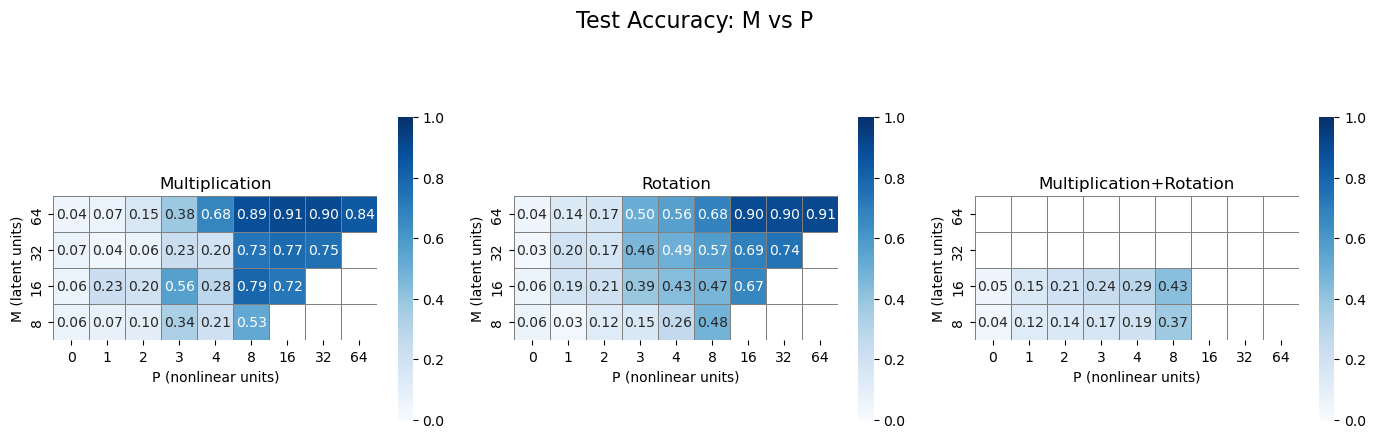

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

results_dir = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\scripts\results\arithmetics_expl"

task_names = ["Multiplication", "Rotation", "Multiplication+Rotation"]
M_values = sorted([8, 16, 32, 64], reverse=True)
P_values = sorted([0, 1, 2, 3, 4, 8, 16, 32, 64])

fig, axes = plt.subplots(1, len(task_names), figsize=(14, 5))

for idx, task in enumerate(task_names):
    matrix = np.full((len(M_values), len(P_values)), np.nan)

    for i, M in enumerate(M_values):
        for j, P in enumerate(P_values):
            filepath = os.path.join(results_dir, f"{task}_M{M}_P{P}.npz")
            if os.path.exists(filepath):
                data = np.load(filepath, allow_pickle=True)
                acc = data["best_test_accuracy"].item()
                if acc is not None:
                    matrix[i, j] = float(acc)

    ax = axes[idx]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        xticklabels=P_values,
        yticklabels=M_values,
        square=True,
        cbar_kws={"shrink": 0.7},
        linewidths=0.5,
        linecolor="gray",
        mask=np.isnan(matrix),
        ax=ax,
    )
    ax.set_xlabel("P (nonlinear units)")
    ax.set_ylabel("M (latent units)")
    ax.set_title(f"{task}")

plt.suptitle("Test Accuracy: M vs P", fontsize=16)
plt.tight_layout()
plt.show()

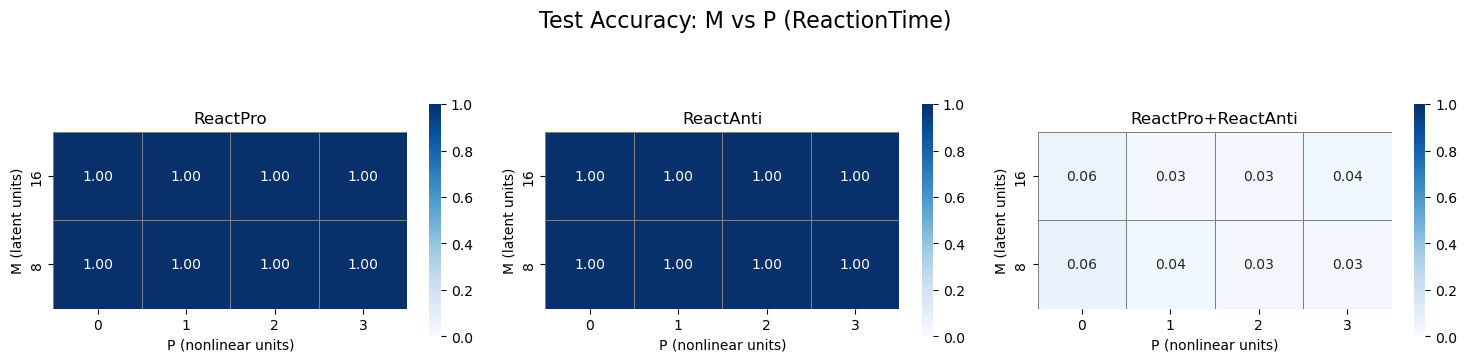

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

results_dir = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\multi_task_training\scripts\results\ReactionTime"

task_names = ["ReactPro", "ReactAnti", "ReactPro+ReactAnti"]
M_values = sorted([8, 16], reverse=True)
P_values = sorted([0, 1, 2, 3])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, task in enumerate(task_names):
    matrix = np.full((len(M_values), len(P_values)), np.nan)

    for i, M in enumerate(M_values):
        for j, P in enumerate(P_values):
            filepath = os.path.join(results_dir, f"{task}_M{M}_P{P}.npz")
            if os.path.exists(filepath):
                data = np.load(filepath, allow_pickle=True)
                acc = data["best_test_accuracy"].item()
                if acc is not None:
                    matrix[i, j] = float(acc)

    ax = axes[idx]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        xticklabels=P_values,
        yticklabels=M_values,
        square=True,
        cbar_kws={"shrink": 0.7},
        linewidths=0.5,
        linecolor="gray",
        mask=np.isnan(matrix),
        ax=ax,
    )
    ax.set_xlabel("P (nonlinear units)")
    ax.set_ylabel("M (latent units)")
    ax.set_title(f"{task}")

plt.suptitle("Test Accuracy: M vs P (ReactionTime)", fontsize=16)
plt.tight_layout()
plt.show()